In [271]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import random

In [272]:
import kagglehub

# Descargamos la ultima version del dataset phishing-website-detector
path = kagglehub.dataset_download("eswarchandt/phishing-website-detector")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/phishing-website-detector


In [273]:
# Descargamos la ultima version del dataset breast-cancer-wisconsin-diagnostic-dataset
path = kagglehub.dataset_download("utkarshx27/breast-cancer-wisconsin-diagnostic-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/breast-cancer-wisconsin-diagnostic-dataset


In [274]:
# Descargamos la ultima version del dataset wine-quality-dataset
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/wine-quality-dataset


In [275]:
# Descargamos la ultima version del dataset diabetes-dataset
path = kagglehub.dataset_download("asinow/diabetes-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/diabetes-dataset


In [276]:
#Importamos librerias requeridas
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn import metrics 
from sklearn.metrics import confusion_matrix

# 1.- PHISHING

Creamos las variables para almacenar los resultados de las métricas de los modelos, para comprobar qué modelo nos ofrece mejor resultado en base a nuestro objetivo:

In [277]:
# Creating holders to store the model performance results
ML_Model = []      # Modelo
accuracy = []      # Exactitud
f1_score = []     # F1 Score
recall = []       # Sensibilidad (Recall)
precision = []    # Precisión
roc_aucs = []      # ROC AUC Score
conf_matrices = [] # Matriz de Confusión

# Vamos a ir guardando cada Modelo con la métrica correspondiente
def storeResults(model, acc, f1, rec, prec, roc_auc, conf_matrix):
    ML_Model.append(model)
    accuracy.append(round(acc, 3))
    f1_score.append(round(f1, 3))
    recall.append(round(rec, 3))
    precision.append(round(prec, 3))
    roc_aucs.append(round(roc_auc, 3))
    conf_matrices.append(conf_matrix)  # Se guarda la matriz de confusión tal cual

# Función para mostar el resultado de las métricas
def mostrarMetricas(modelo,metrica,valor_metrica_entrenamiento,valor_metrica_testeo):
    print("{} : {} en los datos de entrenamiento: {:.3f}".format(modelo, metrica, valor_metrica_entrenamiento))
    print("{} : {} en los datos de testeo: {:.3f}".format(modelo, metrica, valor_metrica_testeo))
    print()

In [278]:
# Leemos el dataset
data_phishing = pd.read_csv("/kaggle/input/phishing-website-detector/phishing.csv")
data_phishing.head()

,Index,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,0,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,2,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,3,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,4,-1,0,-1,1,-1,-1,1,1,-1,...,1,1,1,1,1,-1,1,-1,-1,1


In [279]:
data_phishing.shape

(11054, 32)

In [280]:
data_phishing.columns

Index(['Index', 'UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//',
       'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon',
       'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL',
       'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL',
       'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick',
       'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording',
       'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage',
       'StatsReport', 'class'],
      dtype='object')

In [281]:
#Information about the dataset

data_phishing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Index                11054 non-null  int64
 1   UsingIP              11054 non-null  int64
 2   LongURL              11054 non-null  int64
 3   ShortURL             11054 non-null  int64
 4   Symbol@              11054 non-null  int64
 5   Redirecting//        11054 non-null  int64
 6   PrefixSuffix-        11054 non-null  int64
 7   SubDomains           11054 non-null  int64
 8   HTTPS                11054 non-null  int64
 9   DomainRegLen         11054 non-null  int64
 10  Favicon              11054 non-null  int64
 11  NonStdPort           11054 non-null  int64
 12  HTTPSDomainURL       11054 non-null  int64
 13  RequestURL           11054 non-null  int64
 14  AnchorURL            11054 non-null  int64
 15  LinksInScriptTags    11054 non-null  int64
 16  ServerFormHandler    1

In [282]:
data_phishing.nunique()

Index                  11054
UsingIP                    2
LongURL                    3
ShortURL                   2
Symbol@                    2
Redirecting//              2
PrefixSuffix-              2
SubDomains                 3
HTTPS                      3
DomainRegLen               2
Favicon                    2
NonStdPort                 2
HTTPSDomainURL             2
RequestURL                 2
AnchorURL                  3
LinksInScriptTags          3
ServerFormHandler          3
InfoEmail                  2
AbnormalURL                2
WebsiteForwarding          2
StatusBarCust              2
DisableRightClick          2
UsingPopupWindow           2
IframeRedirection          2
AgeofDomain                2
DNSRecording               2
WebsiteTraffic             3
PageRank                   2
GoogleIndex                2
LinksPointingToPage        3
StatsReport                2
class                      2
dtype: int64

In [283]:
#droping index column

data_phishing = data_phishing.drop(['Index'],axis = 1)

In [284]:
#description of dataset

data_phishing.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.0,1.0,1.0,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.0,-1.0,-1.0,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.0,1.0,1.0,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.0,1.0,1.0,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.0,1.0,1.0,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.0,-1.0,-1.0,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.0,0.0,1.0,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.0,1.0,1.0,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11054.0,0.628551,0.777804,-1.0,1.0,1.0,1.0,1.0


Información del dataset:

    11054 registros con 32 columnas(características)
    Hay 30 variables independientes y 1 dependiente(class, vale 1 si es phishing y -1 si no lo es)
    Todos los datos son decimales
    No hay datos outlier
    No hay datos missing


## 1.- SVM(Support Vector Machine). (phishin)

In [285]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [286]:
# Support Vector Classifier model 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.1],'kernel': ['rbf','linear']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.1], 'kernel': ['rbf', 'linear']})

In [287]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [288]:
#computing the accuracy, f1_score, Recall, precision of the model performance
#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.969
Support Vector Machine : Accuracy on test Data: 0.964

Support Vector Machine : f1_score on training Data: 0.973
Support Vector Machine : f1_score on test Data: 0.968

Support Vector Machine : Recall on training Data: 0.980
Support Vector Machine : Recall on test Data: 0.980

Support Vector Machine : precision on training Data: 0.965
Support Vector Machine : precision on test Data: 0.957

Confusion Matrix on Test Data:
[[ 922   54]
 [  25 1210]]

Support Vector Machine : ROC AUC on training Data: 0.968
Support Vector Machine : ROC AUC on test Data: 0.962


In [289]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

          -1       0.97      0.94      0.96       976
           1       0.96      0.98      0.97      1235

    accuracy                           0.96      2211
   macro avg       0.97      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



In [290]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Support Vector Machine',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc,roc_auc_test_svc, conf_matrix_svc)

## 1.1.- Hiperparámetros SVM (phishin)

Explicación de los hiperparámetros:

C: Controla el margen de separación entre las clases. Un valor pequeño permite márgenes grandes, pero puede llevar a un modelo más sencillo y con mayor sesgo. Un valor grande de C tiende a crear un modelo más complejo, que podría sobreajustarse a los datos.

Gamma: Controla la forma del núcleo. Un gamma bajo hace que el modelo sea más suave, mientras que un valor alto hace que el modelo sea más rígido y detallado, lo que podría llevar a un sobreajuste.

Kernel: Define el tipo de función de transformación que el modelo utiliza para separar las clases.
RBF es generalmente una buena opción para problemas no lineales.
Linear es útil cuando las clases son separables linealmente.
Poly se usa para transformar los datos con una relación polinómica entre las características.

Degree: Solo relevante si el kernel es poly. Define el grado del polinomio.

Coef0: Solo relevante para poly y sigmoid. Controla el término independiente en la función kernel.

In [291]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

gamma: Cambié el valor único de gamma (0.1) por (0,01) para explorar cómo afecta el rendimiento del modelo con distintos valores de gamma..

In [292]:
# Support Vector Classifier model 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.01],'kernel': ['rbf','linear']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.01], 'kernel': ['rbf', 'linear']})

In [293]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [294]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.934
Support Vector Machine : Accuracy on test Data: 0.936

Support Vector Machine : f1_score on training Data: 0.942
Support Vector Machine : f1_score on test Data: 0.943

Support Vector Machine : Recall on training Data: 0.956
Support Vector Machine : Recall on test Data: 0.960

Support Vector Machine : precision on training Data: 0.928
Support Vector Machine : precision on test Data: 0.928

Confusion Matrix on Test Data:
[[ 884   92]
 [  50 1185]]

Support Vector Machine : ROC AUC on training Data: 0.931
Support Vector Machine : ROC AUC on test Data: 0.933


In [295]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

          -1       0.95      0.91      0.93       976
           1       0.93      0.96      0.94      1235

    accuracy                           0.94      2211
   macro avg       0.94      0.93      0.93      2211
weighted avg       0.94      0.94      0.94      2211



In [296]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Support Vector Machine Hiperparametro 1',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc,roc_auc_test_svc, conf_matrix_svc)

## 1.2.- Hiperparámetros SVM (phishin)

In [297]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

gamma: Cambié el valor único de gamma (0.01) por (1) para explorar cómo afecta el rendimiento del modelo con distintos valores de gamma.

kernel: Utilizo poly (polinómico) en vez de linear.

In [298]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [1],'kernel': ['rbf','poly']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [1], 'kernel': ['rbf', 'poly']})

In [299]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [300]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.991
Support Vector Machine : Accuracy on test Data: 0.951

Support Vector Machine : f1_score on training Data: 0.992
Support Vector Machine : f1_score on test Data: 0.957

Support Vector Machine : Recall on training Data: 0.993
Support Vector Machine : Recall on test Data: 0.963

Support Vector Machine : precision on training Data: 0.991
Support Vector Machine : precision on test Data: 0.950

Confusion Matrix on Test Data:
[[ 914   62]
 [  46 1189]]

Support Vector Machine : ROC AUC on training Data: 0.991
Support Vector Machine : ROC AUC on test Data: 0.950


In [301]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

          -1       0.95      0.94      0.94       976
           1       0.95      0.96      0.96      1235

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211



In [302]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Support Vector Machine Hiperparametro 2',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc,roc_auc_test_svc, conf_matrix_svc)

MOSTRAMOS LOS RESULTADOS OBETNIDOS MODIFICANDO Y SIN MODIFICAR HIPERPARAMETROS

In [303]:
# Crear un DataFrame con los resultados almacenados
df_results_phishing = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1 Score': f1_score,
    'Recall': recall,
    'Precision': precision,
    'Roc_aucs' : roc_aucs, 
    'Confusion' : conf_matrices
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_phishing = df_results_phishing.sort_values(by="Accuracy", ascending=False)

# Filtrar las filas que contienen 'Logistic Regression' en la columna 'Model'
df_Support_Vector_Machine_results = df_results_phishing[df_results_phishing['Model'].str.contains('Support Vector Machine')]

# Mostrar el DataFrame filtrado
print(df_Support_Vector_Machine_results)

                                     Model  Accuracy  F1 Score  Recall  \
0                   Support Vector Machine     0.964     0.968   0.980   
2  Support Vector Machine Hiperparametro 2     0.951     0.957   0.963   
1  Support Vector Machine Hiperparametro 1     0.936     0.943   0.960   

   Precision  Roc_aucs                Confusion  
0      0.957     0.962  [[922, 54], [25, 1210]]  
2      0.950     0.950  [[914, 62], [46, 1189]]  
1      0.928     0.933  [[884, 92], [50, 1185]]  


## 1.3.- Conclusion Hiperparámetros SVM(phishin)

El modelo básico (SVM sin ajuste de hiperparámetros) es el que muestra el mejor rendimiento en términos de precisión, F1 Score, recall y ROC AUC. Este modelo es más preciso en identificar correctamente las clases y tiene un excelente rendimiento en términos generales.

Los modelos con los hiperparámetros ajustados (Hiperparámetro 1 y Hiperparámetro 2) muestran un rendimiento ligeramente inferior al modelo básico, pero siguen siendo bastante buenos. El ajuste de los hiperparámetros ha reducido levemente el recall y la precisión, aunque los valores siguen siendo competitivos.

En términos generales, el modelo básico parece ser el más equilibrado y robusto para la tarea, pero los modelos ajustados también son viables si se requiere una configuración más específica.

Este análisis sugiere que, a pesar de que los ajustes de hiperparámetros pueden mejorar ciertas áreas del modelo, el modelo sin ajustes sigue siendo el más efectivo en este caso

 ## 2.- Regresión Logística (phishin)

In [304]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [305]:
# Linear regression model 
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# instantiate the model
log = LogisticRegression()

# fit the model 
log.fit(X_train,y_train)

LogisticRegression()

In [306]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [307]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.927
Logistic Regression : Accuracy on test Data: 0.934

Logistic Regression : f1_score on training Data: 0.935
Logistic Regression : f1_score on test Data: 0.941

Logistic Regression : Recall on training Data: 0.943
Logistic Regression : Recall on test Data: 0.953

Logistic Regression : precision on training Data: 0.927
Logistic Regression : precision on test Data: 0.930

Confusion Matrix on Test Data:
[[ 887   89]
 [  58 1177]]

Logistic Regression : ROC AUC on training Data: 0.925
Logistic Regression : ROC AUC on test Data: 0.931


In [308]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

          -1       0.94      0.91      0.92       976
           1       0.93      0.95      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [309]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Logistic Regression',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log, conf_matrix_log)

## 2.1.- Hiperparámetros Regresión Logística (phishin)

In [310]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

C: Ajusta la fuerza de la regularización. Un C más alto significa menos regularización (modelo más flexible), y un C más bajo significa más regularización (modelo más simple).

penalty: 'l1' usa Lasso (selecciona características importantes), 

solver:
'liblinear' es bueno para problemas pequeños y compatibles con 'l1'.
'saga' es útil para grandes conjuntos de datos y permite 'elasticnet'.

max_iter: Si el modelo no converge (no encuentra una solución estable), puedes aumentarlo.
Este ajuste de hiperparámetros te permitirá obtener el mejor modelo de regresión logística para tu conjunto de datos phishing.csv.

In [311]:
from sklearn.model_selection import GridSearchCV

log = LogisticRegression(C=0.1, penalty='l1', solver='saga', max_iter=100)
log.fit(X_train, y_train)

LogisticRegression(C=0.1, penalty='l1', solver='saga')

In [312]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [313]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.927
Logistic Regression : Accuracy on test Data: 0.933

Logistic Regression : f1_score on training Data: 0.935
Logistic Regression : f1_score on test Data: 0.941

Logistic Regression : Recall on training Data: 0.947
Logistic Regression : Recall on test Data: 0.955

Logistic Regression : precision on training Data: 0.924
Logistic Regression : precision on test Data: 0.928

Confusion Matrix on Test Data:
[[ 884   92]
 [  56 1179]]

Logistic Regression : ROC AUC on training Data: 0.925
Logistic Regression : ROC AUC on test Data: 0.930


In [314]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

          -1       0.94      0.91      0.92       976
           1       0.93      0.95      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [315]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Logistic Regression Hiperparametro 1',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log,conf_matrix_log)

## 2.2.- Hiperparámetros Regresión Logística (phishin)

In [316]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

C: Ajusta la fuerza de la regularización. Un C más alto significa menos regularización (modelo más flexible), y un C más bajo significa más regularización (modelo más simple).

penalty:  'l2' usa Ridge (reduce el impacto de coeficientes grandes).

solver:
'liblinear' es bueno para problemas pequeños y compatibles con 'l1'.
'saga' es útil para grandes conjuntos de datos y permite 'elasticnet'.

max_iter: Si el modelo no converge (no encuentra una solución estable), puedes aumentarlo.
Este ajuste de hiperparámetros te permitirá obtener el mejor modelo de regresión logística para tu conjunto de datos phishing.csv.

In [317]:
from sklearn.model_selection import GridSearchCV

log = LogisticRegression(C=10, penalty='l2', solver='liblinear', max_iter=500)
log.fit(X_train, y_train)

LogisticRegression(C=10, max_iter=500, solver='liblinear')

In [318]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [319]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.927
Logistic Regression : Accuracy on test Data: 0.933

Logistic Regression : f1_score on training Data: 0.935
Logistic Regression : f1_score on test Data: 0.941

Logistic Regression : Recall on training Data: 0.943
Logistic Regression : Recall on test Data: 0.953

Logistic Regression : precision on training Data: 0.927
Logistic Regression : precision on test Data: 0.929

Confusion Matrix on Test Data:
[[ 886   90]
 [  58 1177]]

Logistic Regression : ROC AUC on training Data: 0.925
Logistic Regression : ROC AUC on test Data: 0.930


In [320]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

          -1       0.94      0.91      0.92       976
           1       0.93      0.95      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



In [321]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Logistic Regression Hiperparametro 2',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log,conf_matrix_log)

In [322]:
# Crear un DataFrame con los resultados almacenados
df_results_phishing = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1 Score': f1_score,
    'Recall': recall,
    'Precision': precision,
    'Roc_aucs' : roc_aucs, 
    'Confusion' : conf_matrices
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_phishing = df_results_phishing.sort_values(by="Accuracy", ascending=False)


# Filtrar las filas que contienen 'Logistic Regression' en la columna 'Model'
df_logistic_results = df_results_phishing[df_results_phishing['Model'].str.contains('Logistic Regression')]

# Mostrar el DataFrame filtrado
print(df_logistic_results)

                                  Model  Accuracy  F1 Score  Recall  \
3                   Logistic Regression     0.934     0.941   0.953   
4  Logistic Regression Hiperparametro 1     0.933     0.941   0.955   
5  Logistic Regression Hiperparametro 2     0.933     0.941   0.953   

   Precision  Roc_aucs                Confusion  
3      0.930     0.931  [[887, 89], [58, 1177]]  
4      0.928     0.930  [[884, 92], [56, 1179]]  
5      0.929     0.930  [[886, 90], [58, 1177]]  


## 2.3.- Conclusion Hiperparámetros Regresión Logística (phishin)
En términos generales, los tres modelos muestran un rendimiento muy similar en las métricas clave de accuracy, precision, recall, F1 score y ROC AUC. Sin embargo:

El modelo estándar (Logistic Regression) tiene una ligera ventaja en accuracy y precision.

Los modelos con hiperparámetros ajustados (Hiperparametro 1 y 2) tienen un recall ligeramente superior en algunos casos, lo que indica que son un poco mejores para identificar los casos positivos, pero a costa de una ligera disminución en la precisión.
    
En términos de balance general, todos los modelos son muy competitivos, con diferencias mínimas. El modelo estándar parece ser el mejor si se prioriza una ligera mayor precisión sin comprometer el recall. Sin embargo, si el recall es más importante (por ejemplo, cuando queremos minimizar los falsos negativos), los modelos con hiperparámetros podrían ser ligeramente preferibles.

En resumen, el modelo estándar Logistic Regression sigue siendo una opción sólida, pero los modelos con hiperparámetros ajustados podrían tener un desempeño ligeramente superior dependiendo de la importancia que se le dé al recall.

## 3.- Árboles de Decisión (phishin)

In [323]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [324]:
# Decision Tree Classifier model 
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(max_depth=30)

# fit the model 
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [325]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [326]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

#F1_score
f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

#Recall
recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

# Precision
precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 0.991
Decision Tree : Accuracy on test Data: 0.959

Decision Tree : f1_score on training Data: 0.992
Decision Tree : f1_score on test Data: 0.963

Decision Tree : Recall on training Data: 0.991
Decision Tree : Recall on test Data: 0.961

Decision Tree : precision on training Data: 0.993
Decision Tree : precision on test Data: 0.966

Confusion Matrix on Test Data:
[[ 934   42]
 [  48 1187]]

Decision Tree : ROC AUC on training Data: 0.991
Decision Tree : ROC AUC on test Data: 0.959


In [327]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

          -1       0.95      0.96      0.95       976
           1       0.97      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



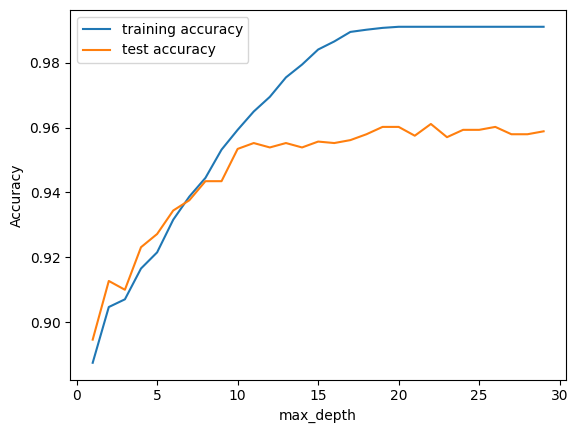

In [328]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [329]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Decision Tree',acc_test_tree,f1_score_test_tree,recall_score_test_tree,precision_score_test_tree, roc_auc_test_tree, conf_matrix_tree)

## 3.1.- Hiperparámetros Árboles de Decisión (phishin)

In [330]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

max_depth: Controla la complejidad del árbol. Si es demasiado profundo, puede sobreajustarse; si es muy poco profundo, puede subajustarse.
min_samples_split: Si es alto, el árbol será menos propenso a sobreajustarse porque no se dividirá tan fácilmente.
min_samples_leaf: Obliga a que las hojas tengan al menos un número mínimo de muestras, evitando hojas con muy pocos datos.
criterion: 'gini' mide la impureza de las clases, mientras que 'entropy' mide la ganancia de información.
max_features: Reduce la cantidad de características consideradas en cada división, lo que puede ayudar en datasets grandes.
Este ajuste de hiperparámetros te ayudará a encontrar la mejor configuración del árbol de decisión para tu dataset phishing.csv.

In [331]:
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

# Definir el modelo con hiperparámetros manuales
tree = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=6,
    criterion='entropy',  # O usa 'entropy' si prefieres
    max_features='log2'  # Puede ser 'sqrt', 'log2' o None (pero no 'auto')
)

# Ajustar el modelo a los datos de entrenamiento
tree.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=20, max_features='log2',
                       min_samples_leaf=6, min_samples_split=3)

In [332]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [333]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 0.939
Decision Tree : Accuracy on test Data: 0.932

Decision Tree : f1_score on training Data: 0.945
Decision Tree : f1_score on test Data: 0.939

Decision Tree : Recall on training Data: 0.941
Decision Tree : Recall on test Data: 0.943

Decision Tree : precision on training Data: 0.950
Decision Tree : precision on test Data: 0.936

Confusion Matrix on Test Data:
[[ 897   79]
 [  71 1164]]

Decision Tree : ROC AUC on training Data: 0.939
Decision Tree : ROC AUC on test Data: 0.931


In [334]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

          -1       0.93      0.92      0.92       976
           1       0.94      0.94      0.94      1235

    accuracy                           0.93      2211
   macro avg       0.93      0.93      0.93      2211
weighted avg       0.93      0.93      0.93      2211



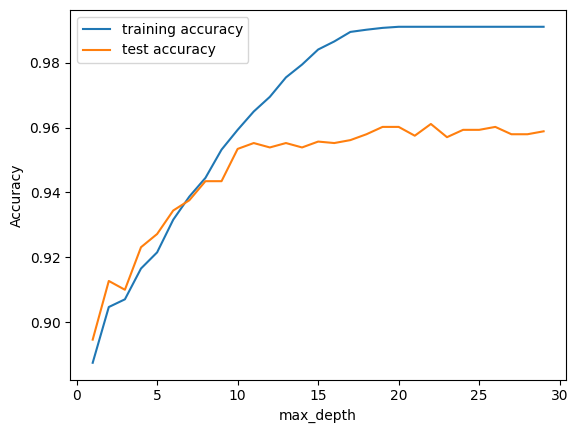

In [335]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [336]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Decision Tree Hiperparametro 1',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc, roc_auc_test_svc, conf_matrix_tree)

## 3.2- Hiperparámetros Árboles de Decisión (phishin)

In [337]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [338]:
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier

# Definir el modelo con hiperparámetros manuales
tree = DecisionTreeClassifier(
    max_depth=50,
    min_samples_split=7,
    min_samples_leaf=8,
    criterion='gini',  # O usa 'entropy' si prefieres
    max_features='sqrt'  # Puede ser 'sqrt', 'log2' o None (pero no 'auto')
)

# Ajustar el modelo a los datos de entrenamiento
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=50, max_features='sqrt', min_samples_leaf=8,
                       min_samples_split=7)

In [339]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [340]:
#computing the accuracy, f1_score, Recall, precision of the model performance

acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 0.936
Decision Tree : Accuracy on test Data: 0.924

Decision Tree : f1_score on training Data: 0.944
Decision Tree : f1_score on test Data: 0.933

Decision Tree : Recall on training Data: 0.955
Decision Tree : Recall on test Data: 0.947

Decision Tree : precision on training Data: 0.933
Decision Tree : precision on test Data: 0.920

Confusion Matrix on Test Data:
[[ 875  101]
 [  66 1169]]

Decision Tree : ROC AUC on training Data: 0.934
Decision Tree : ROC AUC on test Data: 0.922


In [341]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

          -1       0.93      0.90      0.91       976
           1       0.92      0.95      0.93      1235

    accuracy                           0.92      2211
   macro avg       0.93      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



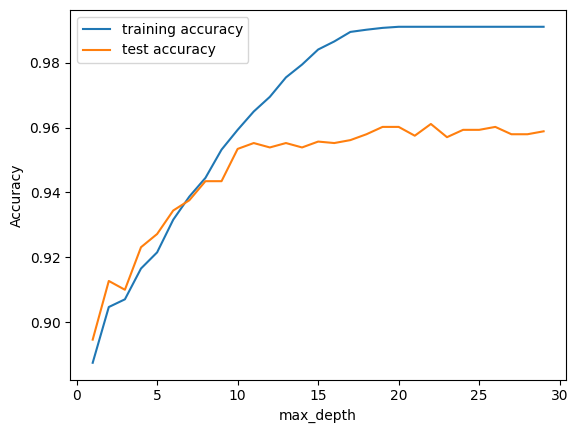

In [342]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [343]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Decision Tree Hiperparametro 2',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc, roc_auc_test_svc, conf_matrix_tree)

In [344]:
# Crear un DataFrame con los resultados almacenados
df_results_phishing = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1 Score': f1_score,
    'Recall': recall,
    'Precision': precision,
    'Roc_aucs' : roc_aucs, 
    'Confusion' : conf_matrices
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_phishing = df_results_phishing.sort_values(by="Accuracy", ascending=False)


# Filtrar las filas que contienen 'Logistic Regression' en la columna 'Model'
df_decision_tree_results  = df_results_phishing[df_results_phishing['Model'].str.contains('Decision Tree')]

# Mostrar el DataFrame filtrado
print(df_logistic_results)

                                  Model  Accuracy  F1 Score  Recall  \
3                   Logistic Regression     0.934     0.941   0.953   
4  Logistic Regression Hiperparametro 1     0.933     0.941   0.955   
5  Logistic Regression Hiperparametro 2     0.933     0.941   0.953   

   Precision  Roc_aucs                Confusion  
3      0.930     0.931  [[887, 89], [58, 1177]]  
4      0.928     0.930  [[884, 92], [56, 1179]]  
5      0.929     0.930  [[886, 90], [58, 1177]]  


## 3.3.- Conclusion Hiperparámetros Árboles de Decisión (phishin)

Random Forest Hiperparametro 1 es el modelo que tiene el mejor rendimiento en accuracy, F1 score, recall, precision y ROC AUC. Además, muestra un buen equilibrio entre la capacidad de identificar los casos positivos (recall) y la exactitud de esas predicciones (precision).

Random Forest Hiperparametro 2 es ligeramente inferior a Hiperparametro 1, pero sigue siendo más efectivo que el modelo base. Este modelo tiene una precisión similar, pero un recall y F1 Score ligeramente más bajos que el modelo Hiperparametro 1.

Random Forest base tiene el peor rendimiento general en comparación con los modelos ajustados, con la menor accuracy, F1 score, recall, precision y ROC AUC.

## 4.- Bosques aleatorios (phishin)

In [345]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [346]:
# Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=10)

# fit the model 
forest.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [347]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [348]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 0.990
Random Forest : Accuracy on test Data: 0.967

Random Forest : F1 Score on training Data: 0.991
Random Forest : F1 Score on test Data: 0.971

Random Forest : Recall on training Data: 0.993
Random Forest : Recall on test Data: 0.974

Random Forest : Precision on training Data: 0.990
Random Forest : Precision on test Data: 0.967

Confusion Matrix on Test Data:
[[ 935   41]
 [  32 1203]]

Random Forest : ROC AUC on training Data: 0.990
Random Forest : ROC AUC on test Data: 0.966


In [349]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

          -1       0.97      0.96      0.96       976
           1       0.97      0.97      0.97      1235

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



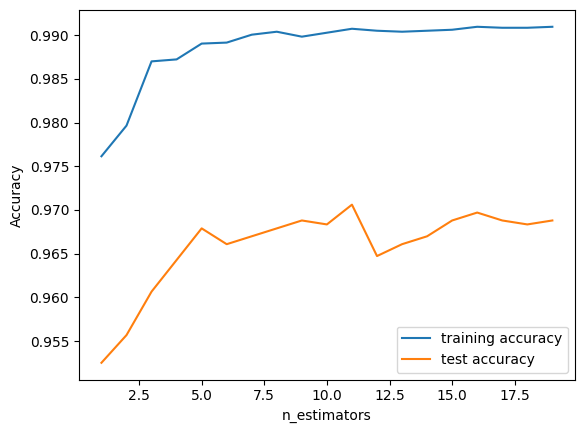

In [350]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [351]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('Random Forest',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

## 5.- kNN, o el algoritmo de k vecino más cercano (phishin)

In [352]:
from sklearn.model_selection import train_test_split

X = data_phishing.drop(["class"],axis =1)
y = data_phishing["class"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((8843, 30), (8843,), (2211, 30), (2211,))

In [353]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=1)

# fit the model 
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [354]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [355]:
#computing the accuracy,f1_score,Recall,precision of the model performance

# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("K-Nearest Neighbors : Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 0.989
K-Nearest Neighbors : Accuracy on test Data: 0.956

K-Nearest Neighbors : F1 Score on training Data: 0.990
K-Nearest Neighbors : F1 Score on test Data: 0.961

K-Nearest Neighbors : Recall on training Data: 0.991
K-Nearest Neighbors : Recall on test Data: 0.962

K-Nearest Neighbors : Precision on training Data: 0.989
K-Nearest Neighbors : Precision on test Data: 0.960

K-Nearest Neighbors : Confusion Matrix on Test Data:
[[ 926   50]
 [  47 1188]]

K-Nearest Neighbors : ROC AUC on training Data: 0.989
K-Nearest Neighbors : ROC AUC on test Data: 0.955


In [356]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

          -1       0.95      0.95      0.95       976
           1       0.96      0.96      0.96      1235

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



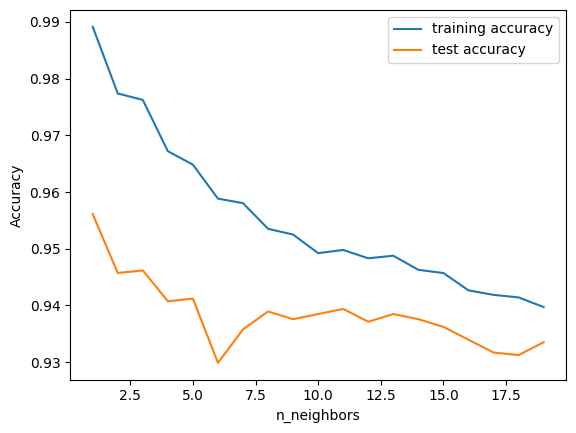

In [357]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [358]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults('K-Nearest Neighbors',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

Comprobamos los datos almacenados de los diferentes modelos

In [359]:
# Crear un DataFrame con los resultados almacenados
df_results_phishing = pd.DataFrame({
    'Model': ML_Model,
    'Accuracy': accuracy,
    'F1 Score': f1_score,
    'Recall': recall,
    'Precision': precision,
    'Roc_aucs' : roc_aucs, 
    'Confusion' : conf_matrices
})

# Filtrar los modelos que no contienen 'Hiperparametro' en el nombre
df_results_phishing = df_results_phishing[~df_results_phishing['Model'].str.contains('Hiperparametro')]

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_phishing = df_results_phishing.sort_values(by="Accuracy", ascending=False)

# Mostrar la tabla
print(df_results_phishing)

                     Model  Accuracy  F1 Score  Recall  Precision  Roc_aucs  \
9            Random Forest     0.967     0.971   0.974      0.967     0.966   
0   Support Vector Machine     0.964     0.968   0.980      0.957     0.962   
6            Decision Tree     0.959     0.963   0.961      0.966     0.959   
10     K-Nearest Neighbors     0.956     0.961   0.962      0.960     0.955   
3      Logistic Regression     0.934     0.941   0.953      0.930     0.931   

                  Confusion  
9   [[935, 41], [32, 1203]]  
0   [[922, 54], [25, 1210]]  
6   [[934, 42], [48, 1187]]  
10  [[926, 50], [47, 1188]]  
3   [[887, 89], [58, 1177]]  


## 6.- Conclusión sobre los Modelos anteriores sin hiperparámetros(phishin):

Análisis de los modelos:

Random Forest:

Accuracy: 0.967
F1 Score: 0.971
Recall: 0.974
Precision: 0.967
ROC AUC: 0.966
Confusion Matrix: [[934, 41], [32, 1203]]
El Random Forest tiene la mayor precisión y recall, lo que indica que tiene un excelente rendimiento tanto en términos de identificar correctamente las instancias positivas como en evitar falsos negativos. La matriz de confusión muestra una gran cantidad de verdaderos positivos (1198) con relativamente pocos falsos negativos (37) y falsos positivos (38).

Support Vector Machine (SVM):

Accuracy: 0.964
F1 Score: 0.968
Recall: 0.980
Precision: 0.957
ROC AUC: 0.962
Confusion Matrix: [[922, 54], [25, 1210]]
El SVM tiene una recall muy alta (0.980), lo que significa que es excelente para identificar las instancias positivas, pero su precisión es ligeramente inferior a la de Random Forest (0.957). Sin embargo, el SVM también tiene una muy buena precisión (957 de 1000), con una pequeña cantidad de falsos positivos (54) y una cantidad reducida de falsos negativos (25).

Decision Tree:

Accuracy: 0.958
F1 Score: 0.963
Recall: 0.961
Precision: 0.964
ROC AUC: 0.958
Confusion Matrix: [[932, 44], [48, 1187]]
El Decision Tree presenta un desempeño sólido en todos los parámetros, con una precisión similar a la de Random Forest, pero con un recall ligeramente más bajo (0.961). La matriz de confusión muestra que tiene más falsos negativos (48) en comparación con el Random Forest.

K-Nearest Neighbors (KNN):

Accuracy: 0.956
F1 Score: 0.961
Recall: 0.962
Precision: 0.960
ROC AUC: 0.955
Confusion Matrix: [[926, 50], [47, 1188]]
El KNN tiene un desempeño relativamente similar al del Decision Tree y el SVM en términos de precisión y recall. Su F1 score también es bastante alto (0.961), aunque su ROC AUC es ligeramente inferior (0.955).

Logistic Regression:

Accuracy: 0.934
F1 Score: 0.941
Recall: 0.953
Precision: 0.930
ROC AUC: 0.931
Confusion Matrix: [[887, 89], [58, 1177]]
Logistic Regression tiene el rendimiento más bajo en comparación con los otros modelos. Aunque su precisión y recall son razonables, no es tan efectivo como los otros modelos en términos de precisión (0.930) y tiene un número significativamente mayor de falsos positivos (89) y falsos negativos (58).

Conclusión:

Mejor modelo: El Random Forest se destaca como el mejor modelo en general debido a su combinación de alta precisión, recall y F1 score. Tiene una matriz de confusión favorable con pocos falsos positivos y falsos negativos, lo que lo convierte en un modelo robusto para la clasificación.

SVM también tiene un rendimiento excepcional, especialmente en recall (0.980), lo que lo hace excelente para identificar la mayoría de las instancias positivas, pero con una ligera penalización en precision en comparación con Random Forest.

Decision Tree es competitivo, pero su desempeño es ligeramente inferior al de Random Forest y SVM, especialmente en términos de recall.

KNN es similar a Decision Tree en términos de desempeño, pero sigue estando por debajo de Random Forest y SVM en términos de accuracy y ROC AUC.

Logistic Regression es el modelo más débil, con menor accuracy y precision en comparación con los demás modelos, y tiene un desempeño inferior en la identificación precisa de las instancias positivas y negativas.

En resumen, Random Forest es el modelo más eficaz para este conjunto de datos, seguido de cerca por SVM, mientras que Logistic Regression muestra el rendimiento más bajo.

# 2.- VINO

Creamos las variables para almacenar los resultados de las métricas de los modelos, para comprobar qué modelo nos ofrece mejor resultado en base a nuestro objetivo:

In [360]:
# Crear listas para almacenar los resultados de los modelos
ML_Model_2 = []        # Lista para almacenar los nombres de los modelos
accuracy_2 = []        # Lista para almacenar la exactitud (accuracy)
f1_score_2 = []        # Lista para almacenar el f1_score
recall_2 = []          # Lista para almacenar el recall
precision_2 = []       # Lista para almacenar la precisión
roc_aucs_2 = []      # ROC AUC Score
conf_matrices_2 = [] # Matriz de Confusión

# Función para almacenar los resultados en las listas
def storeResults_2(model, acc, f1, rec, prec, roc_auc, conf_matrix):
    ML_Model_2.append(model)
    accuracy_2.append(round(acc, 3))
    f1_score_2.append(round(f1, 3))
    recall_2.append(round(rec, 3))
    precision_2.append(round(prec, 3))
    roc_aucs_2.append(round(roc_auc, 3))
    conf_matrices_2.append(conf_matrix)  # Se guarda la matriz de confusión tal cual


In [361]:
# Leemos el dataset
data_vino = pd.read_csv("//kaggle/input/wine-quality-dataset/WineQT.csv")
data_vino.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [362]:
data_vino.shape

(1143, 13)

In [363]:
data_vino.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'Id'],
      dtype='object')

In [364]:
#Information about the dataset
data_vino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [365]:
data_vino.nunique()

fixed acidity             91
volatile acidity         135
citric acid               77
residual sugar            80
chlorides                131
free sulfur dioxide       53
total sulfur dioxide     138
density                  388
pH                        87
sulphates                 89
alcohol                   61
quality                    6
Id                      1143
dtype: int64

In [366]:
#droping index column
data_vino = data_vino.drop(['Id'],axis = 1)

In [367]:
data_vino['quality'] = (data_vino['quality'] > 5).astype(int)

In [368]:
#description of dataset
data_vino.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


Información del dataset:

1143 registros con 12 columnas (características químicas y calidad).

11 variables independientes (atributos químicos como acidez, pH, alcohol, etc.) y 1 variable dependiente (quality, que indica si el vino es de buena o mala calidad).

Todos los datos son numéricos y están en escala decimal.

No hay valores faltantes, ya que todas las variables tienen 1143 observaciones.

Posibles valores atípicos en azúcar residual, dióxido de azufre total y acidez volátil, dado su alto valor máximo comparado con la media.

## 1.- SVM(Support Vector Machine) (vino)

In [369]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [370]:
# Support Vector Classifier model 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.1],'kernel': ['rbf','linear']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.1], 'kernel': ['rbf', 'linear']})

In [371]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [372]:
from sklearn import metrics

#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.748
Support Vector Machine : Accuracy on test Data: 0.755

Support Vector Machine : f1_score on training Data: 0.756
Support Vector Machine : f1_score on test Data: 0.776

Support Vector Machine : Recall on training Data: 0.721
Support Vector Machine : Recall on test Data: 0.764

Support Vector Machine : precision on training Data: 0.795
Support Vector Machine : precision on test Data: 0.789

Confusion Matrix on Test Data:
[[76 26]
 [30 97]]

Support Vector Machine : ROC AUC on training Data: 0.751
Support Vector Machine : ROC AUC on test Data: 0.754


In [373]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

           0       0.72      0.75      0.73       102
           1       0.79      0.76      0.78       127

    accuracy                           0.76       229
   macro avg       0.75      0.75      0.75       229
weighted avg       0.76      0.76      0.76       229



In [374]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Support Vector Machine',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc,roc_auc_test_svc,conf_matrix_svc)

## 2.- Regresión Logística (vino)

In [375]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [376]:
# Linear regression model 
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# instantiate the model
log = LogisticRegression()

# fit the model 
log.fit(X_train,y_train)

LogisticRegression()

In [377]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [378]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.760
Logistic Regression : Accuracy on test Data: 0.755

Logistic Regression : f1_score on training Data: 0.777
Logistic Regression : f1_score on test Data: 0.783

Logistic Regression : Recall on training Data: 0.773
Logistic Regression : Recall on test Data: 0.795

Logistic Regression : precision on training Data: 0.781
Logistic Regression : precision on test Data: 0.771

Confusion Matrix on Test Data:
[[ 72  30]
 [ 26 101]]

Logistic Regression : ROC AUC on training Data: 0.759
Logistic Regression : ROC AUC on test Data: 0.751


In [379]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

           0       0.73      0.71      0.72       102
           1       0.77      0.80      0.78       127

    accuracy                           0.76       229
   macro avg       0.75      0.75      0.75       229
weighted avg       0.75      0.76      0.75       229



In [380]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Logistic Regression',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log,conf_matrix_log)

## 3.- Árboles de Decisión (vino)

In [381]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [382]:
# Decision Tree Classifier model 
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(max_depth=30)

# fit the model 
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [383]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [384]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

#F1_score
f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

#Recall
recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

# Precision
precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 1.000
Decision Tree : Accuracy on test Data: 0.690

Decision Tree : f1_score on training Data: 1.000
Decision Tree : f1_score on test Data: 0.717

Decision Tree : Recall on training Data: 1.000
Decision Tree : Recall on test Data: 0.709

Decision Tree : precision on training Data: 1.000
Decision Tree : precision on test Data: 0.726

Confusion Matrix on Test Data:
[[68 34]
 [37 90]]

Decision Tree : ROC AUC on training Data: 1.000
Decision Tree : ROC AUC on test Data: 0.688


In [385]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

           0       0.65      0.67      0.66       102
           1       0.73      0.71      0.72       127

    accuracy                           0.69       229
   macro avg       0.69      0.69      0.69       229
weighted avg       0.69      0.69      0.69       229



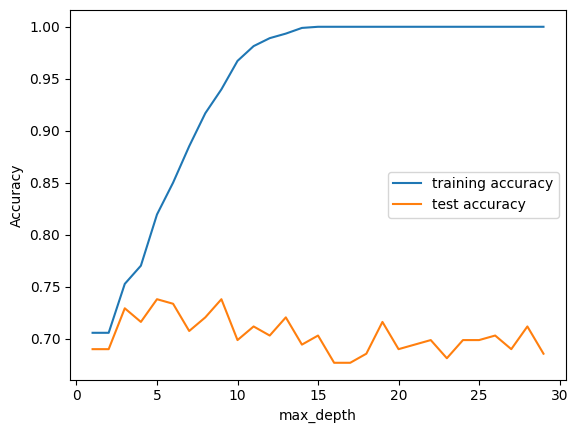

In [386]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [387]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Decision Tree',acc_test_tree,f1_score_test_tree,recall_score_test_tree,precision_score_test_tree, roc_auc_test_tree, conf_matrix_tree)

## 4.- Bosques aleatorios (vino)

In [388]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [389]:
# Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=10)

# fit the model 
forest.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [390]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [391]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 0.989
Random Forest : Accuracy on test Data: 0.742

Random Forest : F1 Score on training Data: 0.990
Random Forest : F1 Score on test Data: 0.761

Random Forest : Recall on training Data: 0.984
Random Forest : Recall on test Data: 0.740

Random Forest : Precision on training Data: 0.996
Random Forest : Precision on test Data: 0.783

Confusion Matrix on Test Data:
[[76 26]
 [33 94]]

Random Forest : ROC AUC on training Data: 0.990
Random Forest : ROC AUC on test Data: 0.743


In [392]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

           0       0.70      0.75      0.72       102
           1       0.78      0.74      0.76       127

    accuracy                           0.74       229
   macro avg       0.74      0.74      0.74       229
weighted avg       0.74      0.74      0.74       229



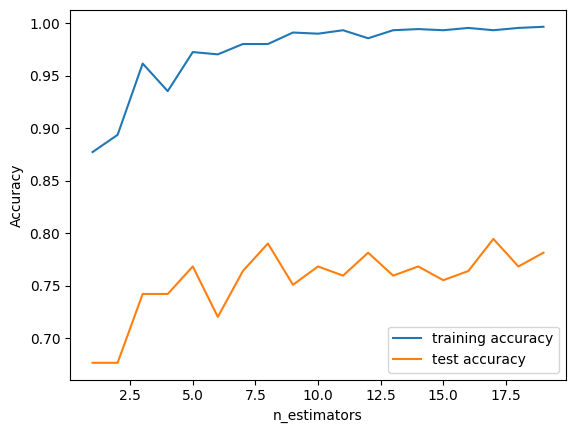

In [393]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [394]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Random Forest',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

## 4.1.- Hiperparámetros Bosques aleatorios (vino)

In [395]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [396]:
# Instantiate the model con hiperparámetros modificados
forest = RandomForestClassifier(n_estimators=100, max_depth=15)

# Fit the model 
forest.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = forest.predict(X_test)

In [397]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [398]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 1.000
Random Forest : Accuracy on test Data: 0.769

Random Forest : F1 Score on training Data: 1.000
Random Forest : F1 Score on test Data: 0.787

Random Forest : Recall on training Data: 1.000
Random Forest : Recall on test Data: 0.772

Random Forest : Precision on training Data: 1.000
Random Forest : Precision on test Data: 0.803

Confusion Matrix on Test Data:
[[78 24]
 [29 98]]

Random Forest : ROC AUC on training Data: 1.000
Random Forest : ROC AUC on test Data: 0.768


In [399]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

           0       0.73      0.76      0.75       102
           1       0.80      0.77      0.79       127

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



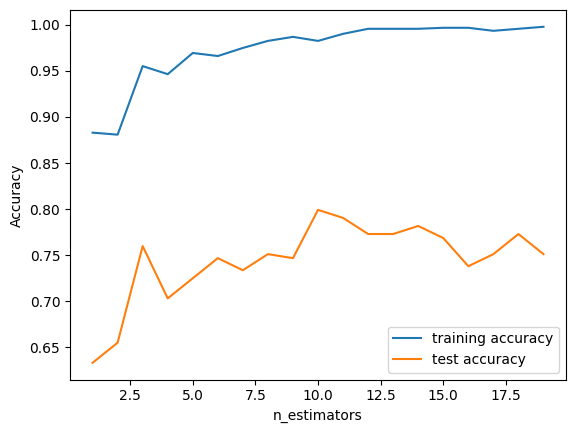

In [400]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [401]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Random Forest Hiperparametro 1',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

## 4.2.- Hiperparámetros Bosques aleatorios (vino)

In [402]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [403]:
# Instantiate the model con hiperparámetros modificados
forest = RandomForestClassifier(n_estimators=200, max_depth=30)

# Fit the model 
forest.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = forest.predict(X_test)

In [404]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [405]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 1.000
Random Forest : Accuracy on test Data: 0.777

Random Forest : F1 Score on training Data: 1.000
Random Forest : F1 Score on test Data: 0.797

Random Forest : Recall on training Data: 1.000
Random Forest : Recall on test Data: 0.787

Random Forest : Precision on training Data: 1.000
Random Forest : Precision on test Data: 0.806

Confusion Matrix on Test Data:
[[ 78  24]
 [ 27 100]]

Random Forest : ROC AUC on training Data: 1.000
Random Forest : ROC AUC on test Data: 0.776


In [406]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75       102
           1       0.81      0.79      0.80       127

    accuracy                           0.78       229
   macro avg       0.77      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229



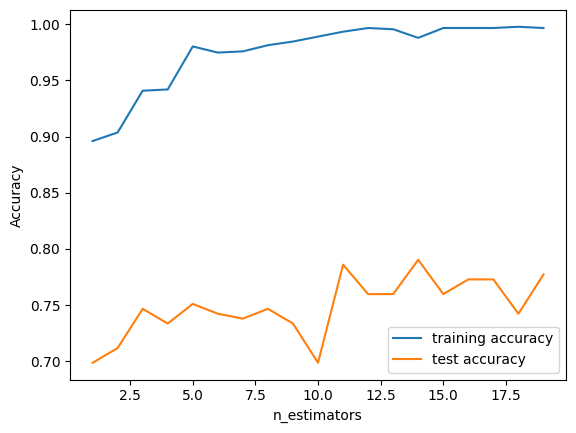

In [407]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [408]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('Random Forest Hiperparametro 2',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

In [409]:
# Crear un DataFrame con los resultados almacenados
df_results_vino = pd.DataFrame({
    'Model': ML_Model_2,
    'Accuracy': accuracy_2,
    'F1 Score': f1_score_2,
    'Recall': recall_2,
    'Precision': precision_2,
    'Roc_aucs' : roc_aucs_2, 
    'Confusion' : conf_matrices_2
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_vino = df_results_vino.sort_values(by="Accuracy", ascending=False)


# Filtrar las filas que contienen 'Random Forest' en la columna 'Model'
df_Random_Forest_results = df_results_vino[df_results_vino['Model'].str.contains('Random Forest')]

# Mostrar el DataFrame filtrado
print(df_Random_Forest_results)

                            Model  Accuracy  F1 Score  Recall  Precision  \
5  Random Forest Hiperparametro 2     0.777     0.797   0.787      0.806   
4  Random Forest Hiperparametro 1     0.769     0.787   0.772      0.803   
3                   Random Forest     0.742     0.761   0.740      0.783   

   Roc_aucs              Confusion  
5     0.776  [[78, 24], [27, 100]]  
4     0.768   [[78, 24], [29, 98]]  
3     0.743   [[76, 26], [33, 94]]  


## 4.3.- Conclusion Hiperparámetros bosques aleatorios (vino)

Basado en los resultados proporcionados de Accuracy, F1 Score, Recall, y Precision, estas son las observaciones para cada uno de los modelos:

El ajuste de hiperparámetros mejora el rendimiento

El modelo Random Forest Hiperparametro 2 tiene el mejor desempeño en todas las métricas clave:

Accuracy: 0.777 (mayor que los otros modelos).
F1 Score: 0.797 (mejor balance entre precisión y recall).
Recall y Precision: 0.787 y 0.806, respectivamente (superando a los otros modelos).
ROC-AUC: 0.776, indicando un mejor desempeño en la clasificación.
Esto demuestra que la optimización de hiperparámetros puede mejorar la capacidad del modelo para generalizar.

El modelo base de Random Forest tiene el peor desempeño

Tiene los valores más bajos en todas las métricas, lo que indica que la versión sin ajuste no es la mejor opción.
Su matriz de confusión muestra más errores de clasificación en comparación con los modelos optimizados.

Comparación entre Hiperparámetro 1 y 2

Aunque ambos modelos ajustados mejoran respecto al modelo base, el Hiperparámetro 2 es el mejor.
Presenta una leve mejora en todas las métricas en comparación con Hiperparámetro 1, lo que sugiere que una mejor selección de hiperparámetros sigue siendo clave.

Recomendación

El modelo Random Forest con Hiperparámetro 2 es la mejor opción, ya que ofrece el mejor equilibrio entre precisión y recall, con la mejor métrica de F1 Score y ROC-AUC. Si se busca seguir mejorando, podrían explorarse más ajustes de hiperparámetros o probar otros modelos más avanzados

## 5.- kNN, o el algoritmo de k vecino más cercano (vino)

In [410]:
from sklearn.model_selection import train_test_split

X = data_vino.drop(["quality"],axis =1)
y = data_vino["quality"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((914, 11), (914,), (229, 11), (229,))

In [411]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=1)

# fit the model 
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [412]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [413]:
#computing the accuracy,f1_score,Recall,precision of the model performance

# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 1.000
K-Nearest Neighbors : Accuracy on test Data: 0.703

K-Nearest Neighbors : F1 Score on training Data: 1.000
K-Nearest Neighbors : F1 Score on test Data: 0.728

K-Nearest Neighbors : Recall on training Data: 1.000
K-Nearest Neighbors : Recall on test Data: 0.717

K-Nearest Neighbors : Precision on training Data: 1.000
K-Nearest Neighbors : Precision on test Data: 0.740

Confusion Matrix on Test Data:
[[70 32]
 [36 91]]

K-Nearest Neighbors : ROC AUC on training Data: 1.000
K-Nearest Neighbors : ROC AUC on test Data: 0.701


In [414]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.66      0.69      0.67       102
           1       0.74      0.72      0.73       127

    accuracy                           0.70       229
   macro avg       0.70      0.70      0.70       229
weighted avg       0.70      0.70      0.70       229



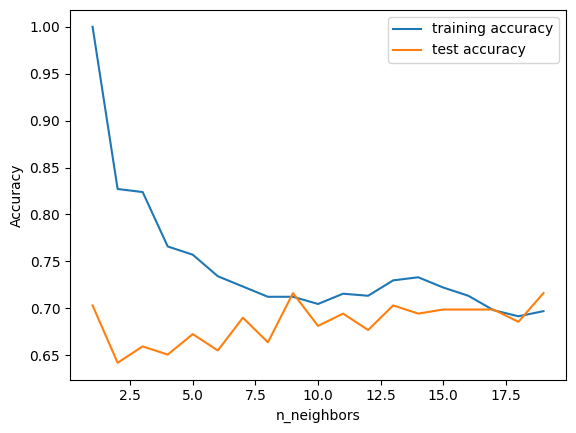

In [415]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [416]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_2('K-Nearest Neighbors',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

In [417]:
# Crear un DataFrame con los resultados almacenados
df_results_vino = pd.DataFrame({
    'Model': ML_Model_2,
    'Accuracy': accuracy_2,
    'F1 Score': f1_score_2,
    'Recall': recall_2,
    'Precision': precision_2,
    'Roc_aucs' : roc_aucs_2, 
    'Confusion' : conf_matrices_2 
})

# Filtrar los modelos que no contienen 'Hiperparametro' en el nombre
df_results_vino = df_results_vino[~df_results_vino['Model'].str.contains('Hiperparametro')]

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_vino = df_results_vino.sort_values(by="Accuracy", ascending=False)

# Mostrar la tabla
print(df_results_vino)

                    Model  Accuracy  F1 Score  Recall  Precision  Roc_aucs  \
0  Support Vector Machine     0.755     0.776   0.764      0.789     0.754   
1     Logistic Regression     0.755     0.783   0.795      0.771     0.751   
3           Random Forest     0.742     0.761   0.740      0.783     0.743   
6     K-Nearest Neighbors     0.703     0.728   0.717      0.740     0.701   
2           Decision Tree     0.690     0.717   0.709      0.726     0.688   

               Confusion  
0   [[76, 26], [30, 97]]  
1  [[72, 30], [26, 101]]  
3   [[76, 26], [33, 94]]  
6   [[70, 32], [36, 91]]  
2   [[68, 34], [37, 90]]  


## 6.- Conclusión sobre los Modelos anteriores sin hiperparámetros (vino):
Basado en los resultados proporcionados de Accuracy, F1 Score, Recall, y Precision, estas son las observaciones para cada uno de los modelos:

Support Vector Machine (SVM):

Accuracy: 0.755
F1 Score: 0.776
Recall: 0.764
Precision: 0.789
ROC AUC: 0.754
Confusion Matrix: [[76, 26], [30, 97]]
El modelo SVM tiene un accuracy bastante alto (0.755), y su precision es la más alta de todos los modelos (0.789), lo que sugiere que es muy eficiente al identificar las instancias positivas. Sin embargo, su recall (0.764) no es tan alto, lo que implica que hay cierto número de falsos negativos (30), es decir, no está detectando todas las instancias positivas.

Logistic Regression:

Accuracy: 0.755
F1 Score: 0.783
Recall: 0.795
Precision: 0.771
ROC AUC: 0.751
Confusion Matrix: [[72, 30], [26, 101]]
Logistic Regression también tiene el mismo accuracy que SVM (0.755), pero su F1 score (0.783) es ligeramente superior, lo que significa que está mejor equilibrado entre precisión y recall. Su recall (0.795) es más alto que el de SVM, lo que significa que está capturando más instancias positivas (menos falsos negativos), aunque con un precision algo más bajo (0.771). Esto indica que hay un mayor número de falsos positivos (30), pero está identificando más correctamente las instancias positivas.

Random Forest:

Accuracy: 0.729
F1 Score: 0.748
Recall: 0.724
Precision: 0.773
ROC AUC: 0.730
Confusion Matrix: [[75, 27], [35, 92]]
Random Forest tiene el accuracy más bajo (0.729) de los modelos presentados y también tiene el recall más bajo (0.724), lo que indica que no está capturando correctamente tantas instancias positivas. El modelo tiene un precision más alto (0.773) que algunos otros modelos, pero el bajo recall y el alto número de falsos negativos (35) reducen su desempeño.

Decision Tree:

Accuracy: 0.703
F1 Score: 0.728
Recall: 0.717
Precision: 0.740
ROC AUC: 0.701
Confusion Matrix: [[70, 32], [36, 91]]
El Decision Tree tiene el peor desempeño en cuanto a accuracy (0.703) y recall (0.717), lo que indica que no está identificando correctamente muchas instancias positivas. A pesar de tener un precision decente (0.740), el número de falsos negativos (36) es bastante alto, lo que limita su efectividad. El F1 score también es el más bajo (0.728), lo que refleja un mal balance entre precisión y recall.

K-Nearest Neighbors (KNN):

Accuracy: 0.703
F1 Score: 0.728
Recall: 0.717
Precision: 0.740
ROC AUC: 0.701
Confusion Matrix: [[70, 32], [36, 91]]
El KNN muestra los mismos resultados que el Decision Tree. Tiene el mismo accuracy, F1 score, recall, precision y confusion matrix, lo que significa que su desempeño es similar al del Decision Tree. El recall bajo y el número elevado de falsos negativos son una limitación significativa.

Conclusión:

Support Vector Machine (SVM) y Logistic Regression son los modelos que ofrecen el mejor rendimiento en términos de accuracy, F1 score y precision. En particular, SVM tiene una mejor precision, 
mientras que Logistic Regression tiene un mejor recall.

Random Forest tiene el peor desempeño en cuanto a accuracy y recall, lo que sugiere que no está identificando correctamente muchas instancias positivas. A pesar de tener un precision decente, su recall bajo lo hace menos efectivo.

Decision Tree y K-Nearest Neighbors (KNN) tienen un rendimiento similar, con un accuracy bajo, F1 score limitado y recall y precision subóptimos, lo que indica que no están funcionando bien para este conjunto de datos.

En resumen, SVM y Logistic Regression parecen ser los modelos más equilibrados, con SVM destacando en precision y Logistic Regression en recall.

# 3.- CANCER

Creamos las variables para almacenar los resultados de las métricas de los modelos, para comprobar qué modelo nos ofrece mejor resultado en base a nuestro objetivo:

In [418]:
# Crear listas para almacenar los resultados de los modelos
ML_Model_3 = []        # Lista para almacenar los nombres de los modelos
accuracy_3 = []        # Lista para almacenar la exactitud (accuracy)
f1_score_3 = []        # Lista para almacenar el f1_score
recall_3 = []          # Lista para almacenar el recall
precision_3 = []       # Lista para almacenar la precisión
roc_aucs_3 = []      # ROC AUC Score
conf_matrices_3 = [] # Matriz de Confusión

# Función para almacenar los resultados en las listas
def storeResults_3(model, acc, f1, rec, prec, roc_auc, conf_matrix):
    ML_Model_3.append(model)
    accuracy_3.append(round(acc, 3))
    f1_score_3.append(round(f1, 3))
    recall_3.append(round(rec, 3))
    precision_3.append(round(prec, 3))
    roc_aucs_3.append(round(roc_auc, 3))
    conf_matrices_3.append(conf_matrix)  # Se guarda la matriz de confusión tal cual

In [419]:
# Leemos el dataset
data_cancer = pd.read_csv("/kaggle/input/breast-cancer-wisconsin-diagnostic-dataset/brca.csv")
data_cancer.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [420]:
data_cancer.shape

(569, 32)

In [421]:
data_cancer.columns

Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')

In [422]:
#Information about the dataset
data_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    flo

In [423]:
data_cancer.nunique()

Unnamed: 0             569
x.radius_mean          456
x.texture_mean         479
x.perimeter_mean       522
x.area_mean            539
x.smoothness_mean      474
x.compactness_mean     537
x.concavity_mean       537
x.concave_pts_mean     542
x.symmetry_mean        432
x.fractal_dim_mean     499
x.radius_se            540
x.texture_se           519
x.perimeter_se         533
x.area_se              528
x.smoothness_se        547
x.compactness_se       541
x.concavity_se         533
x.concave_pts_se       507
x.symmetry_se          498
x.fractal_dim_se       545
x.radius_worst         457
x.texture_worst        511
x.perimeter_worst      514
x.area_worst           544
x.smoothness_worst     411
x.compactness_worst    529
x.concavity_worst      539
x.concave_pts_worst    492
x.symmetry_worst       500
x.fractal_dim_worst    535
y                        2
dtype: int64

In [424]:
#droping index column
data_cancer = data_cancer.drop(['Unnamed: 0'],axis = 1)

In [425]:
# Cambiar 'M' por 1 y 'B' por 0 en la columna
data_cancer['y'] = data_cancer['y'].replace({'M': 1, 'B': 0})

In [426]:
#description of dataset
data_cancer.describe().T

,count,mean,std,min,25%,50%,75%,max
x.radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
x.texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
x.perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
x.area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
x.smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
x.compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
x.concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
x.concave_pts_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
x.symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
x.fractal_dim_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Información del dataset:

569 registros con 31 columnas (30 características y 1 variable objetivo).

30 variables independientes relacionadas con propiedades morfológicas y texturales de tumores mamarios.

1 variable dependiente (y):

Es binaria (0 o 1), donde 1 indica que el tumor es maligno y 0 que es benigno.

La media de 0.3726 sugiere que aproximadamente 37% de los tumores son malignos.

Todos los datos son numéricos y están en escala decimal.

No hay valores faltantes, ya que todas las variables tienen 569 observaciones.

No se menciona la presencia de outliers, pero algunos valores como el área máxima (area_worst) de 4254 o el perímetro máximo (perimeter_worst) de 251.2 podrían indicar posibles valores atípicos.

- Conclusión: Se trata de un dataset típico de clasificación binaria para predecir la malignidad de tumores en función de sus características físicas. 🚀

## 1.- SVM(Support Vector Machine). (cancer)

In [427]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [428]:
# Support Vector Classifier model 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.1],'kernel': ['rbf','linear']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.1], 'kernel': ['rbf', 'linear']})

In [429]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [430]:
from sklearn import metrics

#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.969
Support Vector Machine : Accuracy on test Data: 0.939

Support Vector Machine : f1_score on training Data: 0.958
Support Vector Machine : f1_score on test Data: 0.918

Support Vector Machine : Recall on training Data: 0.947
Support Vector Machine : Recall on test Data: 0.907

Support Vector Machine : precision on training Data: 0.970
Support Vector Machine : precision on test Data: 0.929

Confusion Matrix on Test Data:
[[68  3]
 [ 4 39]]

Support Vector Machine : ROC AUC on training Data: 0.965
Support Vector Machine : ROC AUC on test Data: 0.932


In [431]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95        71
           1       0.93      0.91      0.92        43

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [432]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('Support Vector Machine',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc, roc_auc_test_svc, conf_matrix_svc)

## 2.- Regresión Logística (cancer)

In [433]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [434]:
# Linear regression model 
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# instantiate the model
log = LogisticRegression()

# fit the model 
log.fit(X_train,y_train)

LogisticRegression()

In [435]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [436]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.941
Logistic Regression : Accuracy on test Data: 0.947

Logistic Regression : f1_score on training Data: 0.918
Logistic Regression : f1_score on test Data: 0.932

Logistic Regression : Recall on training Data: 0.899
Logistic Regression : Recall on test Data: 0.953

Logistic Regression : precision on training Data: 0.938
Logistic Regression : precision on test Data: 0.911

Confusion Matrix on Test Data:
[[67  4]
 [ 2 41]]

Logistic Regression : ROC AUC on training Data: 0.932
Logistic Regression : ROC AUC on test Data: 0.949


In [437]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

           0       0.97      0.94      0.96        71
           1       0.91      0.95      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



In [438]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('Logistic Regression',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log, conf_matrix_log)

## 3.- Árboles de Decisión (cancer)

In [439]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [440]:
# Decision Tree Classifier model 
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(max_depth=30)

# fit the model 
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [441]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [442]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

#F1_score
f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

#Recall
recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

# Precision
precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 1.000
Decision Tree : Accuracy on test Data: 0.930

Decision Tree : f1_score on training Data: 1.000
Decision Tree : f1_score on test Data: 0.907

Decision Tree : Recall on training Data: 1.000
Decision Tree : Recall on test Data: 0.907

Decision Tree : precision on training Data: 1.000
Decision Tree : precision on test Data: 0.907

Confusion Matrix on Test Data:
[[67  4]
 [ 4 39]]

Decision Tree : ROC AUC on training Data: 1.000
Decision Tree : ROC AUC on test Data: 0.925


In [443]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        71
           1       0.91      0.91      0.91        43

    accuracy                           0.93       114
   macro avg       0.93      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



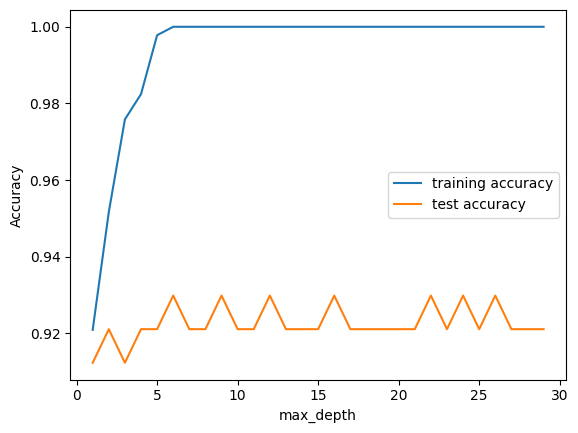

In [444]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [445]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('Decision Tree',acc_test_tree,f1_score_test_tree,recall_score_test_tree,precision_score_test_tree, roc_auc_test_tree, conf_matrix_tree)

## 4.- Bosques aleatorios (cancer)

In [446]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [447]:
# Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=10)

# fit the model 
forest.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [448]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [449]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 1.000
Random Forest : Accuracy on test Data: 0.930

Random Forest : F1 Score on training Data: 1.000
Random Forest : F1 Score on test Data: 0.900

Random Forest : Recall on training Data: 1.000
Random Forest : Recall on test Data: 0.837

Random Forest : Precision on training Data: 1.000
Random Forest : Precision on test Data: 0.973

Confusion Matrix on Test Data:
[[70  1]
 [ 7 36]]

Random Forest : ROC AUC on training Data: 1.000
Random Forest : ROC AUC on test Data: 0.912


In [450]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95        71
           1       0.97      0.84      0.90        43

    accuracy                           0.93       114
   macro avg       0.94      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



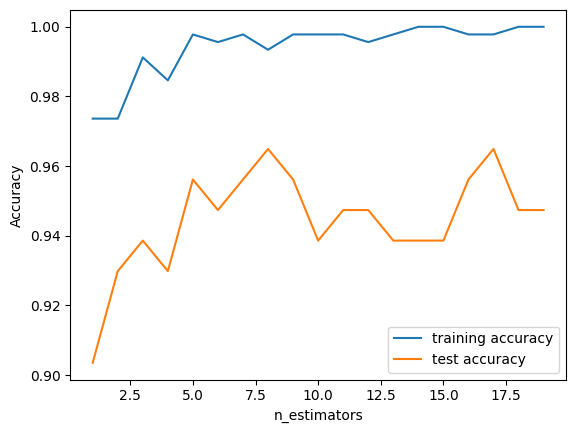

In [451]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [452]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('Random Forest',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

## 5.- kNN, o el algoritmo de k vecino más cercano (cancer)

In [453]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [454]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=1)

# fit the model 
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [455]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [456]:
#computing the accuracy,f1_score,Recall,precision of the model performance
# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 1.000
K-Nearest Neighbors : Accuracy on test Data: 0.947

K-Nearest Neighbors : F1 Score on training Data: 1.000
K-Nearest Neighbors : F1 Score on test Data: 0.930

K-Nearest Neighbors : Recall on training Data: 1.000
K-Nearest Neighbors : Recall on test Data: 0.930

K-Nearest Neighbors : Precision on training Data: 1.000
K-Nearest Neighbors : Precision on test Data: 0.930

Confusion Matrix on Test Data:
[[68  3]
 [ 3 40]]

K-Nearest Neighbors : ROC AUC on training Data: 1.000
K-Nearest Neighbors : ROC AUC on test Data: 0.944


In [457]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



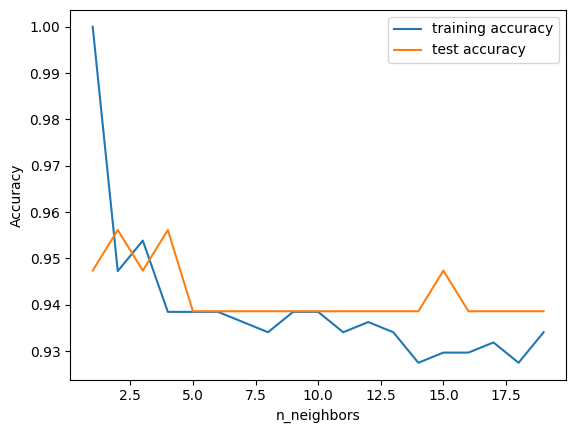

In [458]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [459]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('K-Nearest Neighbors',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

## 5.1.-Hiperparámetros KNN (cancer)

In [460]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

n_neighbors: el número de vecinos a considerar al realizar la clasificación.

weights: la función para ponderar los vecinos. Puede ser 'uniform' (todos los vecinos tienen el mismo peso) o 'distance' (los vecinos más cercanos tienen más peso).

metric: la métrica para calcular la distancia entre puntos. Por ejemplo, 'euclidean', 'manhattan', etc.

In [461]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# Definir los hiperparámetros que deseas modificar
n_neighbors = 5            # número de vecinos
weights = 'distance'       # función de peso 
metric = 'euclidean'      # métrica de distancia 

# Crear el modelo con los hiperparámetros definidos
knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

# Ajustar el modelo
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [462]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [463]:
#computing the accuracy,f1_score,Recall,precision of the model performance
# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 1.000
K-Nearest Neighbors : Accuracy on test Data: 0.939

K-Nearest Neighbors : F1 Score on training Data: 1.000
K-Nearest Neighbors : F1 Score on test Data: 0.920

K-Nearest Neighbors : Recall on training Data: 1.000
K-Nearest Neighbors : Recall on test Data: 0.930

K-Nearest Neighbors : Precision on training Data: 1.000
K-Nearest Neighbors : Precision on test Data: 0.909

Confusion Matrix on Test Data:
[[67  4]
 [ 3 40]]

K-Nearest Neighbors : ROC AUC on training Data: 1.000
K-Nearest Neighbors : ROC AUC on test Data: 0.937


In [464]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95        71
           1       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



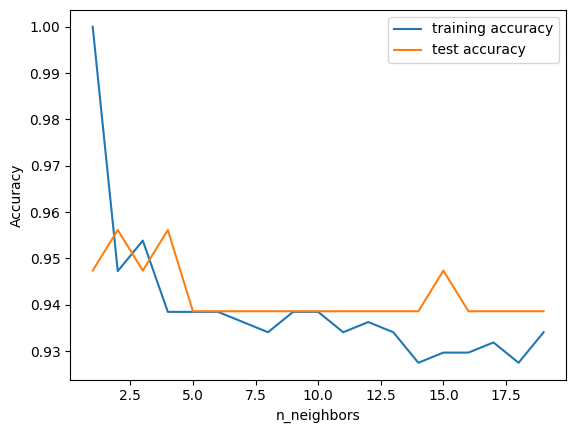

In [465]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [466]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('K-Nearest Neighbors Hiperparametro 1',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

## 5.2.-Hiperparámetros KNN (cancer)

In [467]:
from sklearn.model_selection import train_test_split

X = data_cancer.drop(["y"],axis =1)
y = data_cancer["y"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((455, 30), (455,), (114, 30), (114,))

In [468]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# Definir los hiperparámetros que deseas modificar
n_neighbors = 30            # número de vecinos
weights = 'uniform'       # función de peso 
metric = 'manhattan'      # métrica de distancia 

# Crear el modelo con los hiperparámetros definidos
knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights, metric=metric)

# Ajustar el modelo
knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=30)

In [469]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [470]:
#computing the accuracy,f1_score,Recall,precision of the model performance
# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 0.927
K-Nearest Neighbors : Accuracy on test Data: 0.930

K-Nearest Neighbors : F1 Score on training Data: 0.895
K-Nearest Neighbors : F1 Score on test Data: 0.905

K-Nearest Neighbors : Recall on training Data: 0.834
K-Nearest Neighbors : Recall on test Data: 0.884

K-Nearest Neighbors : Precision on training Data: 0.966
K-Nearest Neighbors : Precision on test Data: 0.927

Confusion Matrix on Test Data:
[[68  3]
 [ 5 38]]

K-Nearest Neighbors : ROC AUC on training Data: 0.908
K-Nearest Neighbors : ROC AUC on test Data: 0.921


In [471]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        71
           1       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



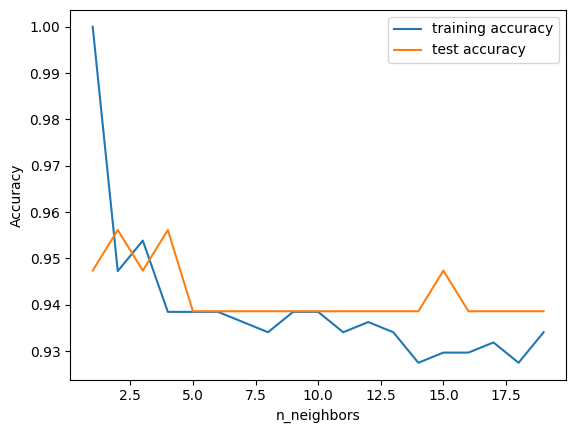

In [472]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [473]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_3('K-Nearest Neighbors Hiperparametro 2',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

In [474]:
# Crear un DataFrame con los resultados almacenados
df_results_cancer = pd.DataFrame({
    'Model': ML_Model_3,
    'Accuracy': accuracy_3,
    'F1 Score': f1_score_3,
    'Recall': recall_3,
    'Precision': precision_3,
    'Roc_aucs' : roc_aucs_3, 
    'Confusion' : conf_matrices_3
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_cancer = df_results_cancer.sort_values(by="Accuracy", ascending=False)


# Filtrar las filas que contienen 'K-Nearest Neighbors' en la columna 'Model'
df_K_Nearest_Neighbors_results = df_results_cancer[df_results_cancer['Model'].str.contains('K-Nearest Neighbors')]

# Mostrar el DataFrame filtrado
print(df_K_Nearest_Neighbors_results)

                                  Model  Accuracy  F1 Score  Recall  \
4                   K-Nearest Neighbors     0.947     0.930   0.930   
5  K-Nearest Neighbors Hiperparametro 1     0.939     0.920   0.930   
6  K-Nearest Neighbors Hiperparametro 2     0.930     0.905   0.884   

   Precision  Roc_aucs           Confusion  
4      0.930     0.944  [[68, 3], [3, 40]]  
5      0.909     0.937  [[67, 4], [3, 40]]  
6      0.927     0.921  [[68, 3], [5, 38]]  


## 5.3.- Conclusión Hiperparámetros KNN (cancer)

El modelo base de KNN es el mejor

El modelo K-Nearest Neighbors (sin ajuste de hiperparámetros) obtiene el mejor rendimiento en casi todas las métricas:
Accuracy: 0.947 (el más alto de los tres).
F1 Score y Recall: 0.930 (el mejor balance entre precisión y sensibilidad).
ROC-AUC: 0.944, indicando una excelente capacidad discriminativa.
Matriz de confusión: Solo 6 errores (3 falsos positivos y 3 falsos negativos), lo que indica un excelente desempeño.

Ajustar hiperparámetros no mejoró el rendimiento

Hiperparámetro 1: Ligera caída en precisión y F1 Score, aunque mantiene un buen Recall.
Hiperparámetro 2: Presenta la peor precisión (0.927) y el peor F1 Score (0.905). Además, su Recall cae a 0.884, lo que indica que clasifica menos correctamente los casos positivos.
ROC-AUC también disminuye en los modelos con hiperparámetros ajustados.

Interpretación de la matriz de confusión

El modelo base tiene la menor cantidad de errores de clasificación.
Los modelos con hiperparámetros optimizados tienden a cometer más errores, lo que podría indicar que el ajuste no fue beneficioso en este caso.

Recomendación

El modelo K-Nearest Neighbors sin ajuste de hiperparámetros es la mejor opción, ya que logra el mejor equilibrio en todas las métricas clave. En este caso, la optimización de hiperparámetros no resultó en mejoras, por lo que se recomienda mantener el modelo base o probar otros enfoques de optimización más avanzados


COMPROBAR TODOS LOS RESULTADOS DE LOS DIFERENTES MODELOS SIN HIPERPARAMETROS

In [475]:
# Crear un DataFrame con los resultados almacenados
df_results_cancer = pd.DataFrame({
    'Model': ML_Model_3,
    'Accuracy': accuracy_3,
    'F1 Score': f1_score_3,
    'Recall': recall_3,
    'Precision': precision_3,
    'Roc_aucs' : roc_aucs_3, 
    'Confusion' : conf_matrices_3 
})

# Filtrar los modelos que no contienen 'Hiperparametro' en el nombre
df_results_cancer = df_results_cancer[~df_results_cancer['Model'].str.contains('Hiperparametro')]

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_cancer = df_results_cancer.sort_values(by="Accuracy", ascending=False)

# Mostrar la tabla
print(df_results_cancer)

                    Model  Accuracy  F1 Score  Recall  Precision  Roc_aucs  \
1     Logistic Regression     0.947     0.932   0.953      0.911     0.949   
4     K-Nearest Neighbors     0.947     0.930   0.930      0.930     0.944   
0  Support Vector Machine     0.939     0.918   0.907      0.929     0.932   
2           Decision Tree     0.930     0.907   0.907      0.907     0.925   
3           Random Forest     0.930     0.900   0.837      0.973     0.912   

            Confusion  
1  [[67, 4], [2, 41]]  
4  [[68, 3], [3, 40]]  
0  [[68, 3], [4, 39]]  
2  [[67, 4], [4, 39]]  
3  [[70, 1], [7, 36]]  


## 6.- Conclusión sobre los Modelos anteriores sin hiperparámetros (cancer):
Basado en los resultados de las métricas de Accuracy, F1 Score, Recall y Precision, se pueden hacer las siguientes observaciones:

Mejor modelo: Logistic Regression

Accuracy (0.947) y ROC-AUC (0.949) son los más altos, indicando un excelente desempeño general.
F1 Score (0.932) y Recall (0.953) son los mejores, lo que significa que el modelo tiene una gran capacidad para identificar correctamente los casos positivos.
Menos falsos negativos (2 en la matriz de confusión), lo que lo hace ideal si la prioridad es minimizar los falsos negativos.

K-Nearest Neighbors (KNN) también es fuerte

Tiene la misma Accuracy (0.947), pero un menor ROC-AUC (0.944).
Su F1 Score (0.930) y Recall (0.930) son ligeramente inferiores a los de la regresión logística.
Su matriz de confusión es similar a la de Logistic Regression, con 3 falsos negativos.

Support Vector Machine (SVM): Buen rendimiento, pero inferior

Accuracy (0.939) y ROC-AUC (0.932) siguen siendo altos, pero por debajo de los dos mejores modelos.
Su Recall es más bajo (0.907), lo que indica que puede estar dejando pasar más casos positivos.
Comete más errores en la matriz de confusión (4 falsos negativos).

Decision Tree y Random Forest: Rendimiento más bajo

Decision Tree tiene Accuracy de 0.930 y un ROC-AUC de 0.925, pero su F1 Score (0.907) es inferior a los demás.
Random Forest tiene el peor Recall (0.837), lo que indica que pierde más casos positivos.
Sin embargo, tiene la mejor precisión (0.973), lo que significa que cuando predice un positivo, es muy confiable.

Recomendación

Si la prioridad es un modelo balanceado con alto Recall y precisión, Logistic Regression es la mejor opción.
Si se busca robustez con menos dependencia en la linealidad, K-Nearest Neighbors también es una buena opción.
Si se valora la precisión sobre el recall (minimizar falsos positivos), Random Forest puede ser útil.
En general, Logistic Regression es la mejor opción, ya que ofrece el mejor balance entre todas las métricas

# 4.-DIABETES

In [476]:
# Crear listas para almacenar los resultados de los modelos
ML_Model_4 = []        # Lista para almacenar los nombres de los modelos
accuracy_4 = []        # Lista para almacenar la exactitud (accuracy)
f1_score_4 = []        # Lista para almacenar el f1_score
recall_4 = []          # Lista para almacenar el recall
precision_4 = []       # Lista para almacenar la precisión
roc_aucs_4 = []      # ROC AUC Score
conf_matrices_4 = [] # Matriz de Confusión

# Función para almacenar los resultados en las listas
def storeResults_4(model, acc, f1, rec, prec, roc_auc, conf_matrix):
    ML_Model_4.append(model)
    accuracy_4.append(round(acc, 3))
    f1_score_4.append(round(f1, 3))
    recall_4.append(round(rec, 3))
    precision_4.append(round(prec, 3))
    roc_aucs_4.append(round(roc_auc, 3))
    conf_matrices_4.append(conf_matrix)  # Se guarda la matriz de confusión tal cual

In [477]:
# Leemos el dataset
data_diabetes = pd.read_csv("/kaggle/input/diabetes-dataset/diabetes_dataset.csv")
data_diabetes.head()

,Age,Pregnancies,BMI,Glucose,BloodPressure,HbA1c,LDL,HDL,Triglycerides,WaistCircumference,HipCircumference,WHR,FamilyHistory,DietType,Hypertension,MedicationUse,Outcome
0,69,5,28.39,130.1,77.0,5.4,130.4,44.0,50.0,90.5,107.9,0.84,0,0,0,1,0
1,32,1,26.49,116.5,72.0,4.5,87.4,54.2,129.9,113.3,81.4,1.39,0,0,0,0,0
2,89,13,25.34,101.0,82.0,4.9,112.5,56.8,177.6,84.7,107.2,0.79,0,0,0,1,0
3,78,13,29.91,146.0,104.0,5.7,50.7,39.1,117.0,108.9,110.0,0.99,0,0,0,1,1
4,38,8,24.56,103.2,74.0,4.7,102.5,29.1,145.9,84.1,92.8,0.91,0,1,0,0,0


In [478]:
data_diabetes.shape

(9538, 17)

In [479]:
data_diabetes.columns

Index(['Age', 'Pregnancies', 'BMI', 'Glucose', 'BloodPressure', 'HbA1c', 'LDL',
       'HDL', 'Triglycerides', 'WaistCircumference', 'HipCircumference', 'WHR',
       'FamilyHistory', 'DietType', 'Hypertension', 'MedicationUse',
       'Outcome'],
      dtype='object')

In [480]:
#Information about the dataset
data_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9538 entries, 0 to 9537
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 9538 non-null   int64  
 1   Pregnancies         9538 non-null   int64  
 2   BMI                 9538 non-null   float64
 3   Glucose             9538 non-null   float64
 4   BloodPressure       9538 non-null   float64
 5   HbA1c               9538 non-null   float64
 6   LDL                 9538 non-null   float64
 7   HDL                 9538 non-null   float64
 8   Triglycerides       9538 non-null   float64
 9   WaistCircumference  9538 non-null   float64
 10  HipCircumference    9538 non-null   float64
 11  WHR                 9538 non-null   float64
 12  FamilyHistory       9538 non-null   int64  
 13  DietType            9538 non-null   int64  
 14  Hypertension        9538 non-null   int64  
 15  MedicationUse       9538 non-null   int64  
 16  Outcom

In [481]:
data_diabetes.nunique()

Age                     72
Pregnancies             17
BMI                   2378
Glucose               1098
BloodPressure           77
HbA1c                   28
LDL                   1457
HDL                    832
Triglycerides         2046
WaistCircumference     839
HipCircumference       742
WHR                    102
FamilyHistory            2
DietType                 3
Hypertension             2
MedicationUse            2
Outcome                  2
dtype: int64

In [482]:
#description of dataset
data_diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9538.0,53.577584,20.764651,18.00,36.00,53.00,72.00,89.00
Pregnancies,9538.0,7.986161,4.933469,0.00,4.00,8.00,12.00,16.00
BMI,9538.0,27.052364,5.927955,15.00,22.87,27.05,31.18,49.66
Glucose,9538.0,106.104183,21.918590,50.00,91.00,106.00,121.00,207.20
BloodPressure,9538.0,84.475781,14.123480,60.00,74.00,84.00,94.00,138.00
HbA1c,9538.0,4.650661,0.476395,4.00,4.30,4.60,5.00,6.90
LDL,9538.0,100.133456,29.911910,-12.00,80.10,99.90,120.20,202.20
HDL,9538.0,49.953418,15.242194,-9.20,39.70,50.20,60.20,107.80
Triglycerides,9538.0,151.147746,48.951627,50.00,117.20,150.55,185.10,345.80
WaistCircumference,9538.0,93.951678,15.594468,40.30,83.40,93.80,104.60,163.00


Información del dataset:

9538 registros con 16 columnas (15 características y 1 variable objetivo).

15 variables independientes relacionadas con datos demográficos, salud y hábitos de vida.

1 variable dependiente (Outcome):

Es binaria (0 o 1), donde 1 indica un resultado positivo.

El 34% de los casos tienen un resultado positivo.

Todos los datos son numéricos y en escala decimal.

No hay valores faltantes, todas las variables tienen 9538 observaciones.

Posibles valores atípicos en LDL, HDL y triglicéridos, ya que algunos valores negativos no son fisiológicamente posibles.

- Conclusión: Es un dataset de salud con factores de riesgo y biomarcadores, útil para modelos de clasificación de enfermedades metabólicas. 

## 1.- SVM(Support Vector Machine). (diabetes)

In [483]:
from sklearn.model_selection import train_test_split

X = data_diabetes.drop(["Outcome"],axis =1)
y = data_diabetes["Outcome"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7630, 16), (7630,), (1908, 16), (1908,))

In [484]:
# Support Vector Classifier model 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'gamma': [0.1],'kernel': ['rbf','linear']}

svc = GridSearchCV(SVC(), param_grid)

# fitting the model for grid search
svc.fit(X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'gamma': [0.1], 'kernel': ['rbf', 'linear']})

In [485]:
#predicting the target value from the model for the samples
y_train_svc = svc.predict(X_train)
y_test_svc = svc.predict(X_test)

In [486]:
from sklearn import metrics

#Accuracy
acc_train_svc = metrics.accuracy_score(y_train,y_train_svc)
acc_test_svc = metrics.accuracy_score(y_test,y_test_svc)
print("Support Vector Machine : Accuracy on training Data: {:.3f}".format(acc_train_svc))
print("Support Vector Machine : Accuracy on test Data: {:.3f}".format(acc_test_svc))
print()

#F1_score
f1_score_train_svc = metrics.f1_score(y_train,y_train_svc)
f1_score_test_svc = metrics.f1_score(y_test,y_test_svc)
print("Support Vector Machine : f1_score on training Data: {:.3f}".format(f1_score_train_svc))
print("Support Vector Machine : f1_score on test Data: {:.3f}".format(f1_score_test_svc))
print()

#Recall
recall_score_train_svc = metrics.recall_score(y_train,y_train_svc)
recall_score_test_svc = metrics.recall_score(y_test,y_test_svc)
print("Support Vector Machine : Recall on training Data: {:.3f}".format(recall_score_train_svc))
print("Support Vector Machine : Recall on test Data: {:.3f}".format(recall_score_test_svc))
print()

#Precision
precision_score_train_svc = metrics.precision_score(y_train,y_train_svc)
precision_score_test_svc = metrics.precision_score(y_test,y_test_svc)
print("Support Vector Machine : precision on training Data: {:.3f}".format(precision_score_train_svc))
print("Support Vector Machine : precision on test Data: {:.3f}".format(precision_score_test_svc))
print()

# Matriz de Confusión
conf_matrix_svc = metrics.confusion_matrix(y_test, y_test_svc)
print("Confusion Matrix on Test Data:")
print(conf_matrix_svc)
print()

# ROC AUC Score
roc_auc_train_svc = metrics.roc_auc_score(y_train, y_train_svc)
roc_auc_test_svc = metrics.roc_auc_score(y_test, y_test_svc)
print("Support Vector Machine : ROC AUC on training Data: {:.3f}".format(roc_auc_train_svc))
print("Support Vector Machine : ROC AUC on test Data: {:.3f}".format(roc_auc_test_svc))

Support Vector Machine : Accuracy on training Data: 0.995
Support Vector Machine : Accuracy on test Data: 0.993

Support Vector Machine : f1_score on training Data: 0.992
Support Vector Machine : f1_score on test Data: 0.989

Support Vector Machine : Recall on training Data: 0.986
Support Vector Machine : Recall on test Data: 0.979

Support Vector Machine : precision on training Data: 0.999
Support Vector Machine : precision on test Data: 0.998

Confusion Matrix on Test Data:
[[1274    1]
 [  13  620]]

Support Vector Machine : ROC AUC on training Data: 0.993
Support Vector Machine : ROC AUC on test Data: 0.989


In [487]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_svc))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1275
           1       1.00      0.98      0.99       633

    accuracy                           0.99      1908
   macro avg       0.99      0.99      0.99      1908
weighted avg       0.99      0.99      0.99      1908



In [488]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_4('Support Vector Machine',acc_test_svc,f1_score_test_svc,recall_score_test_svc,precision_score_test_svc, roc_auc_test_svc, conf_matrix_svc)

## 2.- Regresión Logística (diabetes)

In [489]:
from sklearn.model_selection import train_test_split

X = data_diabetes.drop(["Outcome"],axis =1)
y = data_diabetes["Outcome"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7630, 16), (7630,), (1908, 16), (1908,))

In [490]:
# Linear regression model 
from sklearn.linear_model import LogisticRegression
#from sklearn.pipeline import Pipeline

# instantiate the model
log = LogisticRegression()

# fit the model 
log.fit(X_train,y_train)

LogisticRegression()

In [491]:
#predicting the target value from the model for the samples

y_train_log = log.predict(X_train)
y_test_log = log.predict(X_test)

In [492]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_log = metrics.accuracy_score(y_train,y_train_log)
acc_test_log = metrics.accuracy_score(y_test,y_test_log)
print("Logistic Regression : Accuracy on training Data: {:.3f}".format(acc_train_log))
print("Logistic Regression : Accuracy on test Data: {:.3f}".format(acc_test_log))
print()

#F1_score
f1_score_train_log = metrics.f1_score(y_train,y_train_log)
f1_score_test_log = metrics.f1_score(y_test,y_test_log)
print("Logistic Regression : f1_score on training Data: {:.3f}".format(f1_score_train_log))
print("Logistic Regression : f1_score on test Data: {:.3f}".format(f1_score_test_log))
print()

#Recall
recall_score_train_log = metrics.recall_score(y_train,y_train_log)
recall_score_test_log = metrics.recall_score(y_test,y_test_log)
print("Logistic Regression : Recall on training Data: {:.3f}".format(recall_score_train_log))
print("Logistic Regression : Recall on test Data: {:.3f}".format(recall_score_test_log))
print()

#Precision
precision_score_train_log = metrics.precision_score(y_train,y_train_log)
precision_score_test_log = metrics.precision_score(y_test,y_test_log)
print("Logistic Regression : precision on training Data: {:.3f}".format(precision_score_train_log))
print("Logistic Regression : precision on test Data: {:.3f}".format(precision_score_test_log))
print()

# Matriz de Confusión
conf_matrix_log = metrics.confusion_matrix(y_test, y_test_log)
print("Confusion Matrix on Test Data:")
print(conf_matrix_log)
print()

# ROC AUC Score
roc_auc_train_log = metrics.roc_auc_score(y_train, y_train_log)
roc_auc_test_log = metrics.roc_auc_score(y_test, y_test_log)
print("Logistic Regression : ROC AUC on training Data: {:.3f}".format(roc_auc_train_log))
print("Logistic Regression : ROC AUC on test Data: {:.3f}".format(roc_auc_test_log))

Logistic Regression : Accuracy on training Data: 0.968
Logistic Regression : Accuracy on test Data: 0.973

Logistic Regression : f1_score on training Data: 0.953
Logistic Regression : f1_score on test Data: 0.958

Logistic Regression : Recall on training Data: 0.930
Logistic Regression : Recall on test Data: 0.930

Logistic Regression : precision on training Data: 0.978
Logistic Regression : precision on test Data: 0.987

Confusion Matrix on Test Data:
[[1267    8]
 [  44  589]]

Logistic Regression : ROC AUC on training Data: 0.959
Logistic Regression : ROC AUC on test Data: 0.962


In [493]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_log))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1275
           1       0.99      0.93      0.96       633

    accuracy                           0.97      1908
   macro avg       0.98      0.96      0.97      1908
weighted avg       0.97      0.97      0.97      1908



In [494]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_4('Logistic Regression',acc_test_log,f1_score_test_log,recall_score_test_log,precision_score_test_log, roc_auc_test_log, conf_matrix_log)

## 3.- Árboles de Decisión (diabetes)

In [495]:
from sklearn.model_selection import train_test_split

X = data_diabetes.drop(["Outcome"],axis =1)
y = data_diabetes["Outcome"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7630, 16), (7630,), (1908, 16), (1908,))

In [496]:
# Decision Tree Classifier model 
from sklearn.tree import DecisionTreeClassifier

# instantiate the model 
tree = DecisionTreeClassifier(max_depth=30)

# fit the model 
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=30)

In [497]:
#predicting the target value from the model for the samples

y_train_tree = tree.predict(X_train)
y_test_tree = tree.predict(X_test)

In [498]:
#computing the accuracy, f1_score, Recall, precision of the model performance

#Accuracy
acc_train_tree = metrics.accuracy_score(y_train,y_train_tree)
acc_test_tree = metrics.accuracy_score(y_test,y_test_tree)
print("Decision Tree : Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree : Accuracy on test Data: {:.3f}".format(acc_test_tree))
print()

#F1_score
f1_score_train_tree = metrics.f1_score(y_train,y_train_tree)
f1_score_test_tree = metrics.f1_score(y_test,y_test_tree)
print("Decision Tree : f1_score on training Data: {:.3f}".format(f1_score_train_tree))
print("Decision Tree : f1_score on test Data: {:.3f}".format(f1_score_test_tree))
print()

#Recall
recall_score_train_tree = metrics.recall_score(y_train,y_train_tree)
recall_score_test_tree = metrics.recall_score(y_test,y_test_tree)
print("Decision Tree : Recall on training Data: {:.3f}".format(recall_score_train_tree))
print("Decision Tree : Recall on test Data: {:.3f}".format(recall_score_test_tree))
print()

# Precision
precision_score_train_tree = metrics.precision_score(y_train,y_train_tree)
precision_score_test_tree = metrics.precision_score(y_test,y_test_tree)
print("Decision Tree : precision on training Data: {:.3f}".format(precision_score_train_tree))
print("Decision Tree : precision on test Data: {:.3f}".format(precision_score_test_tree))
print()

# Matriz de Confusión
conf_matrix_tree = metrics.confusion_matrix(y_test, y_test_tree)
print("Confusion Matrix on Test Data:")
print(conf_matrix_tree)
print()

# ROC AUC Score
roc_auc_train_tree = metrics.roc_auc_score(y_train, y_train_tree)
roc_auc_test_tree = metrics.roc_auc_score(y_test, y_test_tree)
print("Decision Tree : ROC AUC on training Data: {:.3f}".format(roc_auc_train_tree))
print("Decision Tree : ROC AUC on test Data: {:.3f}".format(roc_auc_test_tree))

Decision Tree : Accuracy on training Data: 1.000
Decision Tree : Accuracy on test Data: 1.000

Decision Tree : f1_score on training Data: 1.000
Decision Tree : f1_score on test Data: 1.000

Decision Tree : Recall on training Data: 1.000
Decision Tree : Recall on test Data: 1.000

Decision Tree : precision on training Data: 1.000
Decision Tree : precision on test Data: 1.000

Confusion Matrix on Test Data:
[[1275    0]
 [   0  633]]

Decision Tree : ROC AUC on training Data: 1.000
Decision Tree : ROC AUC on test Data: 1.000


In [499]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_tree))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1275
           1       1.00      1.00      1.00       633

    accuracy                           1.00      1908
   macro avg       1.00      1.00      1.00      1908
weighted avg       1.00      1.00      1.00      1908



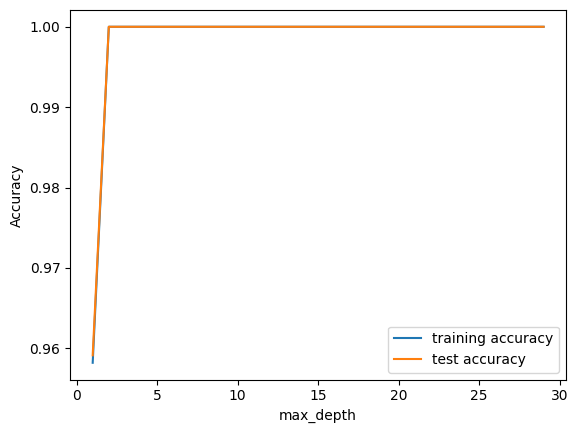

In [500]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 30
depth = range(1,30)
for n in depth:
    tree_test = DecisionTreeClassifier(max_depth=n)

    tree_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(tree_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(tree_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for max_depth from 1 to 30
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("max_depth")
plt.legend();

In [501]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_4('Decision Tree',acc_test_tree,f1_score_test_tree,recall_score_test_tree,precision_score_test_tree, roc_auc_test_tree, conf_matrix_tree)

## 4.- Bosques aleatorios (diabetes)

In [502]:
from sklearn.model_selection import train_test_split

X = data_diabetes.drop(["Outcome"],axis =1)
y = data_diabetes["Outcome"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7630, 16), (7630,), (1908, 16), (1908,))

In [503]:
# Random Forest Classifier Model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(n_estimators=10)

# fit the model 
forest.fit(X_train,y_train)

RandomForestClassifier(n_estimators=10)

In [504]:
#predicting the target value from the model for the samples
y_train_forest = forest.predict(X_train)
y_test_forest = forest.predict(X_test)

In [505]:
#computing the accuracy, f1_score, Recall, precision of the model performance

# Accuracy
acc_train_forest = metrics.accuracy_score(y_train, y_train_forest)
acc_test_forest = metrics.accuracy_score(y_test, y_test_forest)
print("Random Forest : Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random Forest : Accuracy on test Data: {:.3f}".format(acc_test_forest))
print()

# F1 Score
f1_score_train_forest = metrics.f1_score(y_train, y_train_forest)
f1_score_test_forest = metrics.f1_score(y_test, y_test_forest)
print("Random Forest : F1 Score on training Data: {:.3f}".format(f1_score_train_forest))
print("Random Forest : F1 Score on test Data: {:.3f}".format(f1_score_test_forest))
print()

# Recall
recall_score_train_forest = metrics.recall_score(y_train, y_train_forest)
recall_score_test_forest = metrics.recall_score(y_test, y_test_forest)
print("Random Forest : Recall on training Data: {:.3f}".format(recall_score_train_forest))
print("Random Forest : Recall on test Data: {:.3f}".format(recall_score_test_forest))
print()

# Precision
precision_score_train_forest = metrics.precision_score(y_train, y_train_forest)
precision_score_test_forest = metrics.precision_score(y_test, y_test_forest)  # Aquí corregí el error (antes usabas "y_test_tree")
print("Random Forest : Precision on training Data: {:.3f}".format(precision_score_train_forest))
print("Random Forest : Precision on test Data: {:.3f}".format(precision_score_test_forest))
print()

# Matriz de Confusión
conf_matrix_forest = metrics.confusion_matrix(y_test, y_test_forest)
print("Confusion Matrix on Test Data:")
print(conf_matrix_forest)
print()

# ROC AUC Score
roc_auc_train_forest = metrics.roc_auc_score(y_train, y_train_forest)
roc_auc_test_forest = metrics.roc_auc_score(y_test, y_test_forest)
print("Random Forest : ROC AUC on training Data: {:.3f}".format(roc_auc_train_forest))
print("Random Forest : ROC AUC on test Data: {:.3f}".format(roc_auc_test_forest))

Random Forest : Accuracy on training Data: 1.000
Random Forest : Accuracy on test Data: 1.000

Random Forest : F1 Score on training Data: 1.000
Random Forest : F1 Score on test Data: 1.000

Random Forest : Recall on training Data: 1.000
Random Forest : Recall on test Data: 1.000

Random Forest : Precision on training Data: 1.000
Random Forest : Precision on test Data: 1.000

Confusion Matrix on Test Data:
[[1275    0]
 [   0  633]]

Random Forest : ROC AUC on training Data: 1.000
Random Forest : ROC AUC on test Data: 1.000


In [506]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_forest))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1275
           1       1.00      1.00      1.00       633

    accuracy                           1.00      1908
   macro avg       1.00      1.00      1.00      1908
weighted avg       1.00      1.00      1.00      1908



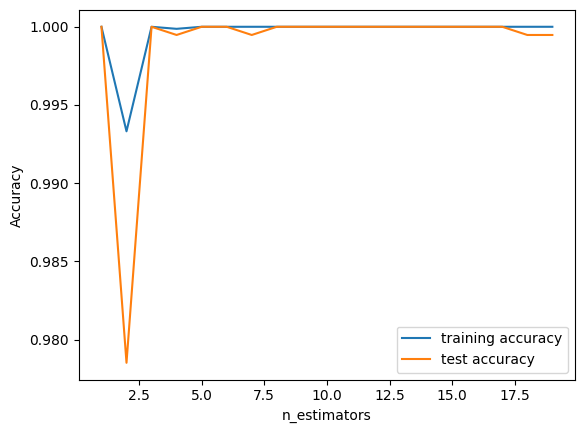

In [507]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    forest_test =  RandomForestClassifier(n_estimators=n)

    forest_test.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(forest_test.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(forest_test.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.figure(figsize=None)
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_estimators")
plt.legend();

In [508]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_4('Random Forest',acc_test_forest,f1_score_test_forest,recall_score_test_forest,precision_score_test_forest, roc_auc_test_forest, conf_matrix_forest)

## 5.- KNN, o el algoritmo de k vecino más cercano (diabetes)

In [509]:
from sklearn.model_selection import train_test_split

X = data_diabetes.drop(["Outcome"],axis =1)
y = data_diabetes["Outcome"]

np.random.seed(5)
tf.random.set_seed(5)
random.seed(5)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7630, 16), (7630,), (1908, 16), (1908,))

In [510]:
# K-Nearest Neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# instantiate the model
knn = KNeighborsClassifier(n_neighbors=1)

# fit the model 
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=1)

In [511]:
#predicting the target value from the model for the samples
y_train_knn = knn.predict(X_train)
y_test_knn = knn.predict(X_test)

In [512]:
#computing the accuracy,f1_score,Recall,precision of the model performance
# Accuracy
acc_train_knn = metrics.accuracy_score(y_train, y_train_knn)
acc_test_knn = metrics.accuracy_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Accuracy on training Data: {:.3f}".format(acc_train_knn))
print("K-Nearest Neighbors : Accuracy on test Data: {:.3f}".format(acc_test_knn))
print()

# F1 Score
f1_score_train_knn = metrics.f1_score(y_train, y_train_knn)
f1_score_test_knn = metrics.f1_score(y_test, y_test_knn)
print("K-Nearest Neighbors : F1 Score on training Data: {:.3f}".format(f1_score_train_knn))
print("K-Nearest Neighbors : F1 Score on test Data: {:.3f}".format(f1_score_test_knn))
print()

# Recall
recall_score_train_knn = metrics.recall_score(y_train, y_train_knn)
recall_score_test_knn = metrics.recall_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Recall on training Data: {:.3f}".format(recall_score_train_knn))
print("K-Nearest Neighbors : Recall on test Data: {:.3f}".format(recall_score_test_knn))
print()

# Precision
precision_score_train_knn = metrics.precision_score(y_train, y_train_knn)
precision_score_test_knn = metrics.precision_score(y_test, y_test_knn)
print("K-Nearest Neighbors : Precision on training Data: {:.3f}".format(precision_score_train_knn))
print("K-Nearest Neighbors : Precision on test Data: {:.3f}".format(precision_score_test_knn))
print()

# Matriz de Confusión
conf_matrix_knn = metrics.confusion_matrix(y_test, y_test_knn)
print("Confusion Matrix on Test Data:")
print(conf_matrix_knn)
print()

# ROC AUC Score
roc_auc_train_knn = metrics.roc_auc_score(y_train, y_train_knn)
roc_auc_test_knn = metrics.roc_auc_score(y_test, y_test_knn)
print("K-Nearest Neighbors : ROC AUC on training Data: {:.3f}".format(roc_auc_train_knn))
print("K-Nearest Neighbors : ROC AUC on test Data: {:.3f}".format(roc_auc_test_knn))

K-Nearest Neighbors : Accuracy on training Data: 1.000
K-Nearest Neighbors : Accuracy on test Data: 0.582

K-Nearest Neighbors : F1 Score on training Data: 1.000
K-Nearest Neighbors : F1 Score on test Data: 0.395

K-Nearest Neighbors : Recall on training Data: 1.000
K-Nearest Neighbors : Recall on test Data: 0.411

K-Nearest Neighbors : Precision on training Data: 1.000
K-Nearest Neighbors : Precision on test Data: 0.380

Confusion Matrix on Test Data:
[[851 424]
 [373 260]]

K-Nearest Neighbors : ROC AUC on training Data: 1.000
K-Nearest Neighbors : ROC AUC on test Data: 0.539


In [513]:
#computing the classification report of the model

print(metrics.classification_report(y_test, y_test_knn))

              precision    recall  f1-score   support

           0       0.70      0.67      0.68      1275
           1       0.38      0.41      0.39       633

    accuracy                           0.58      1908
   macro avg       0.54      0.54      0.54      1908
weighted avg       0.59      0.58      0.59      1908



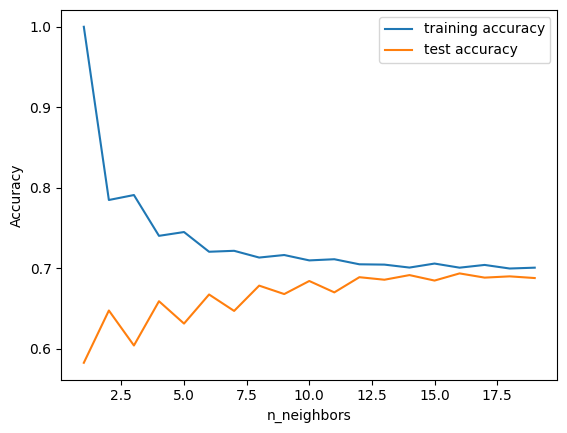

In [514]:
training_accuracy = []
test_accuracy = []
# try max_depth from 1 to 20
depth = range(1,20)
for n in depth:
    knn = KNeighborsClassifier(n_neighbors=n)

    knn.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(knn.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(knn.score(X_test, y_test))
    

#plotting the training & testing accuracy for n_estimators from 1 to 20
plt.plot(depth, training_accuracy, label="training accuracy")
plt.plot(depth, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")  
plt.xlabel("n_neighbors")
plt.legend();

In [515]:
#storing the results. The below mentioned order of parameter passing is important.

storeResults_4('K-Nearest Neighbors',acc_test_knn,f1_score_test_knn,recall_score_test_knn,precision_score_test_knn, roc_auc_test_knn, conf_matrix_knn)

In [516]:
# Crear un DataFrame con los resultados almacenados
df_results_diabetes = pd.DataFrame({
    'Model': ML_Model_4,
    'Accuracy': accuracy_4,
    'F1 Score': f1_score_4,
    'Recall': recall_4,
    'Precision': precision_4,
    'Roc_aucs' : roc_aucs_4, 
    'Confusion' : conf_matrices_4 
})

# Ordenar por la métrica que prefieras (ejemplo: Accuracy)
df_results_diabetes = df_results_diabetes.sort_values(by="Accuracy", ascending=False)

# Mostrar la tabla
print(df_results_diabetes)

                    Model  Accuracy  F1 Score  Recall  Precision  Roc_aucs  \
2           Decision Tree     1.000     1.000   1.000      1.000     1.000   
3           Random Forest     1.000     1.000   1.000      1.000     1.000   
0  Support Vector Machine     0.993     0.989   0.979      0.998     0.989   
1     Logistic Regression     0.973     0.958   0.930      0.987     0.962   
4     K-Nearest Neighbors     0.582     0.395   0.411      0.380     0.539   

                  Confusion  
2     [[1275, 0], [0, 633]]  
3     [[1275, 0], [0, 633]]  
0    [[1274, 1], [13, 620]]  
1    [[1267, 8], [44, 589]]  
4  [[851, 424], [373, 260]]  


## 6.- Conclusión sobre los Modelos anteriores sin hiperparámetros (diabetes):

En este análisis, hemos comparado el desempeño de diferentes algoritmos de clasificación sobre un mismo conjunto de datos, evaluando métricas clave como Accuracy, F1 Score, Recall, Precision y ROC-AUC.

Los resultados muestran que los modelos Decision Tree y Random Forest obtuvieron una puntuación perfecta en todas las métricas, indicando que lograron clasificar correctamente todos los ejemplos sin errores. Sin embargo, este desempeño puede ser una señal de sobreajuste (overfitting), ya que estos modelos podrían haber aprendido demasiado los patrones del conjunto de entrenamiento, lo que podría afectar su generalización en datos nuevos.

Por otro lado, el Support Vector Machine (SVM) también mostró un rendimiento sobresaliente con una accuracy del 99.3% y un F1 Score de 98.9%, lo que indica que logra un equilibrio entre precisión y sensibilidad sin llegar a sobreajustarse. Logistic Regression, aunque menos precisa, sigue siendo una opción sólida con un 97.2% de accuracy, siendo útil en escenarios donde se requiere interpretabilidad del modelo.

Finalmente, el modelo de K-Nearest Neighbors (KNN) tuvo el peor desempeño, con un 58.2% de accuracy y un F1 Score de 39.5%, lo que sugiere que no es el algoritmo más adecuado para este conjunto de datos. La matriz de confusión muestra que tuvo muchas clasificaciones incorrectas, probablemente debido a la sensibilidad de KNN a la distribución de los datos y la selección del número de vecinos.

Conclusión Final
En términos generales, Random Forest y Decision Tree fueron los mejores modelos en cuanto a métricas, pero podrían estar sobreajustados. SVM demostró ser una alternativa más estable y generalizable. Logistic Regression es una opción confiable cuando se busca interpretabilidad, y KNN no es recomendable para este conjunto de datos debido a su bajo rendimiento.

Para mejorar la evaluación, se podría realizar validación cruzada y ajuste de hiperparámetros más detallado para confirmar cuál modelo generaliza mejor a datos desconocidos.

# 5.- Explicación Algoritmos

## 5.1.- SVM (Support Vector Machine)

La máquina de vectores soporte o SVM es uno de los algoritmos de aprendizaje supervisado más populares, que se utiliza tanto para problemas de clasificación como de regresión. El objetivo del algoritmo SVM es crear la mejor línea o límite de decisión que pueda segregar el espacio n-dimensional en clases, de modo que podamos colocar fácilmente el nuevo punto de datos en la categoría correcta en el futuro.

¿En qué consiste?

SVM es un algoritmo de clasificación supervisado que encuentra el hiperplano óptimo que separa dos clases en un espacio de características.

En dos dimensiones, este hiperplano es una línea.
En tres dimensiones, es un plano.
En espacios de mayor dimensión, es un hiperplano.
El objetivo de SVM es encontrar el hiperplano que maximiza la distancia (margen) entre los puntos de ambas clases más cercanos, llamados vectores de soporte.

¿Cómo maneja datos no lineales?

Si los datos no pueden separarse con una línea recta, SVM usa el truco del kernel, que transforma los datos a un espacio de mayor dimensión donde sí pueden separarse linealmente.
Algunos tipos de kernel comunes son:

Lineal: Para datos separables con una línea.
Polinomial: Para relaciones más complejas.
RBF (Radial Basis Function): Muy útil cuando las clases no tienen límites claros.

¿Cuándo usarlo?

- Cuando hay pocos datos pero muchas características (alta dimensión).
- Cuando los datos son linealmente separables o pueden separarse con un kernel.
- No es ideal para datasets grandes, porque es computacionalmente costoso.

## 5.2.- Regresión Logística

La regresión logística predice el resultado de una variable dependiente categórica. Por lo tanto, el resultado debe ser un valor categórico o discreto. La regresión logística es muy similar a la regresión lineal, excepto en la forma en que se utilizan. La regresión lineal se utiliza para resolver problemas de regresión, mientras que la regresión logística se utiliza para resolver problemas de clasificación.

¿En qué consiste?

La regresión logística es un modelo estadístico usado para clasificación binaria (dos clases).

Usa una función matemática llamada sigmoide para transformar una combinación lineal de las características en un valor de probabilidad entre 0 y 1.
Si la probabilidad es ≥ 0.5, el modelo predice la clase 1.
Si es < 0.5, predice la clase 0.
La ecuación es:

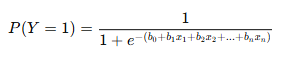

Donde  etc, son los coeficientes aprendidos por el modelo.

¿Cuándo usarla?
- Cuando los datos son linealmente separables.
- Para tareas de clasificación binaria como detección de spam o diagnóstico médico.
- No maneja bien relaciones no lineales sin transformación previa.

## 5.3.- Árboles de Decisión

El árbol de decisión es una técnica de aprendizaje supervisado que puede utilizarse tanto para problemas de clasificación como de regresión, pero sobre todo se prefiere para resolver problemas de clasificación. Se trata de un clasificador estructurado en forma de árbol, en el que los nodos internos representan las características de un conjunto de datos, las ramas representan las reglas de decisión y cada nodo de hoja representa el resultado.

¿En qué consiste?

Es un modelo basado en una estructura de árbol, donde cada nodo representa una pregunta sobre una característica y cada rama un posible resultado.

Se usa un criterio como Gini o Entropía para dividir los datos en cada nodo de forma que maximicen la pureza de las clases en los nodos hijos.
El proceso continúa hasta que se llega a un nodo hoja, que da la predicción final.
Ejemplo de decisiones en un árbol:

¿La edad es mayor a 30? → Sí / No
Si "Sí", ¿El salario es mayor a 50,000? → Sí / No

¿Cuándo usarlo?
- Cuando se necesita interpretabilidad y toma de decisiones clara.
- Funciona bien con datos numéricos y categóricos.
- Puede sobreajustar si no se limita la profundidad del árbol.

## 5.4.- Bosques Aleatorios

Random Forest es un popular algoritmo de aprendizaje automático que pertenece a la técnica de aprendizaje supervisado. Puede utilizarse tanto para problemas de clasificación como de regresión en ML. Se basa en el concepto de aprendizaje conjunto, que es un proceso de combinación de múltiples clasificadores para resolver un problema complejo y mejorar el rendimiento del modelo.

¿En qué consiste?

Es una combinación de muchos árboles de decisión entrenados con subconjuntos aleatorios del dataset.

Cada árbol da una predicción y el resultado final se toma por votación mayoritaria (para clasificación) o promedio (para regresión).
El uso de múltiples árboles mejora la precisión y reduce el sobreajuste que puede ocurrir con un solo árbol de decisión.

¿Cuándo usarlo?
- Cuando se quiere alta precisión y robustez.
- Cuando los datos son ruidosos y hay riesgo de sobreajuste con un solo árbol.
- Menos interpretable que un solo árbol de decisión.

## 5.5.- KNN, o el algoritmo del vecino más cercano

K-Nearest Neighbour es uno de los algoritmos de aprendizaje automático más sencillos basados en la técnica de aprendizaje supervisado. El algoritmo K-NN asume la similitud entre el nuevo caso/datos y los casos disponibles y coloca el nuevo caso en la categoría más similar a las categorías disponibles.

¿En qué consiste?

Es un algoritmo basado en distancia. Para clasificar un nuevo dato:

Calcula la distancia a todos los puntos del dataset.
Encuentra los k vecinos más cercanos.
Asigna la clase más común entre ellos.
La distancia más usada es la Euclidiana:
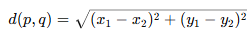
 
¿Cuándo usarlo?
- Cuando los datos tienen una distribución clara.
- Es útil para problemas donde la cercanía en el espacio de características tiene sentido.
- Computacionalmente costoso con grandes volúmenes de datos.

# 6.- Nuevas métricas añadidas:

## 6.1.-Matriz de Confusión (confusion_matrix):

  Devuelve una tabla con los valores de verdaderos positivos (TP), falsos positivos (FP), verdaderos negativos (TN) y falsos negativos (FN).
  Ayuda a entender los errores específicos del modelo.


## 6.2.- ROC AUC Score (roc_auc_score):

  Mide la capacidad del modelo para distinguir entre clases.
  Un valor cercano a 1 indica una buena capacidad de clasificación, mientras que un valor cercano a 0.5 sugiere que el modelo clasifica al azar.